# Decoding Customer Value: A Retention Intelligence Framework


## Business Context

Direct-to-consumer (D2C) brands generate large amounts of behavioral data through purchases, reviews, subscriptions, and promotional interactions. While this creates opportunities for customer intelligence, it also raises an important business question:

> Is customer growth being driven by genuine loyalty, or primarily by discounts and promotional incentives?

This project analyzes transactional and behavioral data for ~3,900 customers of a U.S.-based online fashion retailer to better understand customer value, engagement patterns, and promotional dependency.

Since the dataset does not contain timestamps, churn labels, or predefined loyalty metrics, loyalty cannot be observed directly. Instead, this notebook constructs proxy-based loyalty frameworks using customer behavior, spending patterns, subscription activity, and promotional usage.

---

## Objective

This notebook:

1. Cleans and validates the dataset
2. Performs exploratory and behavioral analysis
3. Engineers features related to customer value, loyalty, and promo dependency
4. Builds and compares multiple loyalty frameworks
5. Segments customers into meaningful business groups
6. Exports an enriched dataset for SQL analysis and Power BI dashboarding


---
## Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

plt.style.use('seaborn-v0_8-whitegrid')

# Consistent color palette
PALETTE_MAIN = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#ABD9E9']
PALETTE_CAT  = sns.color_palette('Set2', 8)
PALETTE_DIV  = sns.diverging_palette(220, 20, as_cmap=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)


---
##  Data Loading and Initial Inspection

This dataset is a **cross-sectional snapshot** -- one row per customer, 3900 rows total. There are no timestamps anywhere, so all behavioral inference must come from static signals. We cannot track how a customer evolves over time; we can only see where they stand right now.

**What each key column represents:**
- `Category` -- the specific product line that the customer is purchasing from
- `Purchase Amount (USD)` -- the customer's most recent single transaction value (not a lifetime total).
- `Previous Purchases` -- count of all purchases made *before* the current one.
- `Frequency of Purchases` -- their self-reported or system-recorded purchase cadence, from Weekly to Annually.
- `Discount Applied` / `Promo Code Used` -- whether *this particular transaction* involved a discount or promo code.
- `Review Rating` -- rating left for the most recent purchase (the only direct sentiment signal).
- `Subscription Status` -- whether the customer currently holds a subscription.


In [2]:
df = pd.read_csv('../sql_dataset/Raw/Dataset.csv')
df_raw = df.copy()  # preserve a clean copy for reference

print(f"Dataset Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print("\nFirst 5 Rows:")
display(df.head(5))


Dataset Shape: (3900, 18)

Data Types:
Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object

First 5 Rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.100,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.100,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.100,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.500,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.700,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Numerical Distrubution

In [3]:
numerical_cols = ['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', "Previous Purchases"]
cat_cols = []
for col in df.columns:
    if col not in numerical_cols:
        cat_cols.append(col)

In [4]:
print("="*30)
print('Numerical values Summary:')
print("="*30)
display(df[numerical_cols].describe())


Numerical values Summary:


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000,3900.000,3900.000,3863.000,3900.000
mean,1950.500,44.068,59.764,3.750,25.352
std,1125.977,15.208,23.685,0.717,14.447
min,1.000,18.000,20.000,2.500,1.000
25%,975.750,31.000,39.000,3.100,13.000
50%,1950.500,44.000,60.000,3.800,25.000
75%,2925.250,57.000,81.000,4.400,38.000
max,3900.000,70.000,100.000,5.000,50.000


**Key observations:**
- `Purchase Amount (USD)` ranges from \$20–\$100 with a mean near \$60 — a relatively flat, 
bounded distribution. No extreme outliers expected.
- `Previous Purchases` spans 1–50 with mean ~25 — roughly uniform. This makes it a usable tenure 
proxy without transformation concerns.
- `Review Rating` is bounded 2.5–5.0, approximately uniform — not a typical satisfaction curve 
(where most users cluster at extremes). This uniformity deserves attention in the satisfaction analysis.
- `Age` ranges 18–70 with mean ~44. A fairly mature customer base.


---
## Categorical Distribution Summary

Before any preprocessing, it is useful to understand the distribution of every categorical variable. 
Label inconsistencies, unexpected values, or extreme imbalances are easier to catch visually than 
programmatically.


In [5]:
for col in cat_cols:
    summary = pd.DataFrame({'Count': df[col].value_counts(),'Percentage (%)': (df[col].value_counts(normalize=True) * 100).round(2)})

    print(f"\n{'='*30}")
    print(f"{col}")
    print(f"{'='*30}")
    display(summary)


Gender


,Count,Percentage (%)
Gender,,
Male,2652,68.000
Female,1248,32.000



Item Purchased


,Count,Percentage (%)
Item Purchased,,
Blouse,171,4.380
Pants,171,4.380
Jewelry,171,4.380
Shirt,169,4.330
Dress,166,4.260
Sweater,164,4.210
Jacket,163,4.180
Coat,161,4.130
Sunglasses,161,4.130



Category


...

,Count,Percentage (%)
Promo Code Used,,
No,2223,57.000
Yes,1677,43.000



Payment Method


,Count,Percentage (%)
Payment Method,,
PayPal,677,17.360
Credit Card,671,17.210
Cash,670,17.180
Debit Card,636,16.310
Venmo,634,16.260
Bank Transfer,612,15.690



Frequency of Purchases


,Count,Percentage (%)
Frequency of Purchases,,
Every 3 Months,584,14.970
Annually,572,14.670
Quarterly,563,14.440
Monthly,553,14.180
Bi-Weekly,547,14.030
Fortnightly,542,13.900
Weekly,539,13.820


### Observations from Initial Inspection

The following observations are clearly noticeable and further analysis would be reuqired to understand the data:

- **Gender**: The dataset is ~68% Male. This likely reflects the brand's historical acquisition 
channel mix or product focus. Female customers (~32%) are a minority in records but may represent 
a commercially underserved segment worth targeting.
- **Subscription Status**: is roughly split with approximately 27% subscribers. Subscribers represent 
a committed customer cohort regardless of other attributes.
- **Previous Purchases** ranges from 1 to 50. The hard ceiling at 50 suggests this variable is likely capped in the source system, which means our heaviest buyers may be under-counted.
- **Frequency of Purchases** has 7 distinct levels. Some of these overlap in meaning (e.g., "Fortnightly" and "Bi-Weekly" both mean every two weeks), so we will need to handle that during encoding.
- **Discount Applied and Promo Code Used** are both binary Yes/No fields. They may move together, but they are not identical in concept: one can be a brand-initiated markdown, the other a customer-entered code. We will examine this relationship closely.
- **Category**: Clothing dominates (1,737 records), followed by Accessories (1,240). Outerwear (324) 
is the smallest — likely seasonal or price-sensitive. Category mix will matter when assessing 
category level retention proxy.
- **Review Rating** is the only column with missing data (37 nulls out of 3900 rows). Everything else is complete.
- **Discount/Promo Applied**: Almost perfectly correlated binary fields — 43% of customers used a 
promo code with a discount applied. This is a meaningful share, worth interrogating.
- **Season**: Near-uniform seasonal distribution — suggests no strong seasonal bias in data collection.



---
## Missing Values

Only `Review Rating` contains nulls — 37 records (0.95% of the dataset). This is not a data quality 
crisis, but it requires deliberate handling. Dropping these rows would lose valid customer records 
entirely. Median imputation is preferable since rating is bounded (2.5–5.0) and the distribution 
appears approximately uniform. 

Rather than filling them with the global median, we will impute using the **median rating within each Category**.
This has been done as customer satisfaction tends to vary by product to product. For instance, food might consistently rate differently than accessories. Hence we use the category wise median value of ratings, representing a structural pattern instead of filling it all with global median value.


In [6]:
print("="*30)
print("Distribution of Missing Values:")
print("="*30)
print(df.isna().sum())

Distribution of Missing Values:
Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64


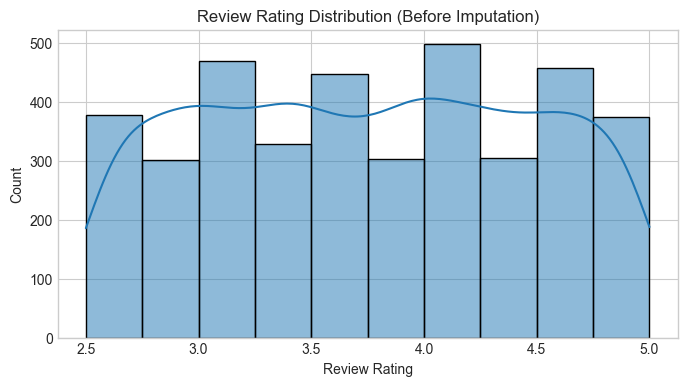

Missing Review Ratings after imputation: 0


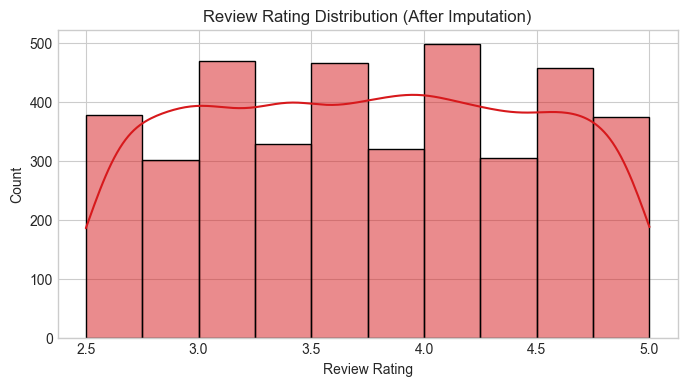

In [7]:
# Distribution before imputation
plt.figure(figsize=(8, 4))
sns.histplot(df['Review Rating'].dropna(), bins=10, kde=True)
plt.title('Review Rating Distribution (Before Imputation)')
plt.xlabel('Review Rating')
plt.ylabel('Count')
plt.show()

# Impute with category median
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Missing Review Ratings after imputation: {df['Review Rating'].isnull().sum()}")

# Distribution after imputation
plt.figure(figsize=(8, 4))
sns.histplot(df['Review Rating'], bins=10, kde=True, color='#D7191C')
plt.title('Review Rating Distribution (After Imputation)')
plt.xlabel('Review Rating')
plt.ylabel('Count')
plt.show()


---
## Checking for Duplicate rows


In [8]:
print('Fully duplicated rows: ',  df.duplicated().sum())
print('Duplicate Customer IDs:', df['Customer ID'].duplicated().sum())

Fully duplicated rows:  0
Duplicate Customer IDs: 0


---
## Data Preprocessing

Preprocessing decisions are guided by analytical necessity and business logic — not mechanical 
pipeline application. Every transformation is justified.


---
## Critical Data Validation: Promo Code vs Discount Applied

A structural check is warranted here. If `Promo Code Used = Yes` and `Discount Applied = No` exists, 
that represents a data integrity problem — a promo code that did not trigger a discount. Similarly, 
`Discount Applied = Yes` without a promo code would suggest a system-applied discount (e.g., 
membership pricing), which is a conceptually different construct.


In [9]:
promo_cross = pd.crosstab(df['Promo Code Used'], df['Discount Applied'],
                           margins=True, margins_name='Total')
print('Promo Code Used × Discount Applied:')
display(promo_cross)


Promo Code Used × Discount Applied:


Discount Applied,No,Yes,Total
Promo Code Used,,,
No,2223,0,2223
Yes,0,1677,1677
Total,2223,1677,3900


### Interpretation: *The two fields are perfectly aligned*
Every promo code user received a discount; no discounts were applied without a code

**Implication**: `Promo Code Used` and `Discount Applied` are REDUNDANT. We will use a single binary

---
### Standardize Categorical Columns

Text columns can contain inconsistent casing or trailing whitespace that would create duplicate categories (e.g., "Male " vs "Male"). We strip whitespace and apply Title Case across all object columns to prevent this.


In [10]:
# Redefine cat_cols to be safe
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Show unique values for each categorical column to confirm
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {sorted(unique_vals)}")
    print()


Gender (2 unique): ['Female', 'Male']

Item Purchased (25 unique): ['Backpack', 'Belt', 'Blouse', 'Boots', 'Coat', 'Dress', 'Gloves', 'Handbag', 'Hat', 'Hoodie', 'Jacket', 'Jeans', 'Jewelry', 'Pants', 'Sandals', 'Scarf', 'Shirt', 'Shoes', 'Shorts', 'Skirt', 'Sneakers', 'Socks', 'Sunglasses', 'Sweater', 'T-Shirt']

Category (4 unique): ['Accessories', 'Clothing', 'Footwear', 'Outerwear']

Location (50 unique): ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\132257657.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


---
### 3.4 Encode Binary Columns as 0/1

Three columns (`Discount Applied`, `Promo Code Used`, `Subscription Status`) contain Yes/No text values. We create new integer-encoded columns with an `_Enc` suffix, keeping the originals intact for readability. And drop the `Promo Code used` column as it is redundant.


In [11]:
# Binary encoding of Yes/No fields
# Rationale: These flags need to be numeric for feature engineering calculations.
# The mapping is deterministic and reversible.
df['Discount_Applied_Enc'] = df['Discount Applied'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Promo_Code_Used_Enc'] = df['Promo Code Used'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Subscription_Status_Enc'] = df['Subscription Status'].apply(lambda x: 1 if x == 'Yes' else 0)

print("Encoding verification (first 5 rows):")
display(df[['Discount Applied', 'Discount_Applied_Enc',
            'Promo Code Used', 'Promo_Code_Used_Enc',
            'Subscription Status', 'Subscription_Status_Enc']].head())

# Note: promo_binary == discount_binary; discount_binary is retained for documentation clarity

Encoding verification (first 5 rows):


,Discount Applied,Discount_Applied_Enc,Promo Code Used,Promo_Code_Used_Enc,Subscription Status,Subscription_Status_Enc
0,Yes,1,Yes,1,Yes,1
1,Yes,1,Yes,1,Yes,1
2,Yes,1,Yes,1,Yes,1
3,Yes,1,Yes,1,Yes,1
4,Yes,1,Yes,1,Yes,1


---
### Encoding Frequency Score as numeric
 The dataset has no timestamps, but `Frequency of Purchases` gives us an ordinal signal of how often a customer shops. We map it to annual purchase count equivalents — this gives a numeric score that directly weights high-frequency buyers in our value formula.

It captures behavioral cadence. A customer who shops weekly is fundamentally different from one who shops annually, even if both have the same spend per visit.

Thing to note- "Fortnightly" and "Bi-weekly" mean every two weeks, so both map to the same number. Similar is the case of "Every 3 Months" and "Quarterly"

In [12]:
# Frequency of Purchases — ordinal encoding

freq_order = {
    'Annually': 1,
    'Every 3 Months': 4, 
    'Quarterly': 4, #same as "every 3 months"
    'Monthly': 12,
    'Bi-Weekly': 26,
    'Fortnightly': 26, #same as "bi-weekly"
    'Weekly': 52
}
df['freq_score'] = df['Frequency of Purchases'].map(freq_order)

print('Frequency score distribution:')
print(df['freq_score'].value_counts().sort_index())


Frequency score distribution:
freq_score
1      572
4     1147
12     553
26    1089
52     539
Name: count, dtype: int64


In [13]:
print("Checking missing values in `freq_score:` \n",df.freq_score.isnull().sum())

Checking missing values in `freq_score:` 
 0


In [14]:
# Category standardization check
# Ensure no label inconsistencies exist (whitespace, casing issues)
for col in ['Category', 'Gender', 'Season', 'Subscription Status']:
    unique_vals = df[col].unique()
    print(f'{col}: {sorted(unique_vals)}')


Category: ['Accessories', 'Clothing', 'Footwear', 'Outerwear']
Gender: ['Female', 'Male']
Season: ['Fall', 'Spring', 'Summer', 'Winter']
Subscription Status: ['No', 'Yes']


In [15]:
# Final dataset state
print(f'Rows: {len(df):,}')
print(f'Columns (post-engineering): {df.shape[1]}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')


Rows: 3,900
Columns (post-engineering): 22
Missing values remaining: 0


---
##  Univariate Analysis

Univariate analysis is the foundation of customer understanding. Before examining relationships, 
we must understand the shape of each individual variable — its distribution, central tendency, 
spread, and any anomalies. Each chart here is designed to answer a specific business question.


###  Purchase Amount Distribution —  Revenue Profile


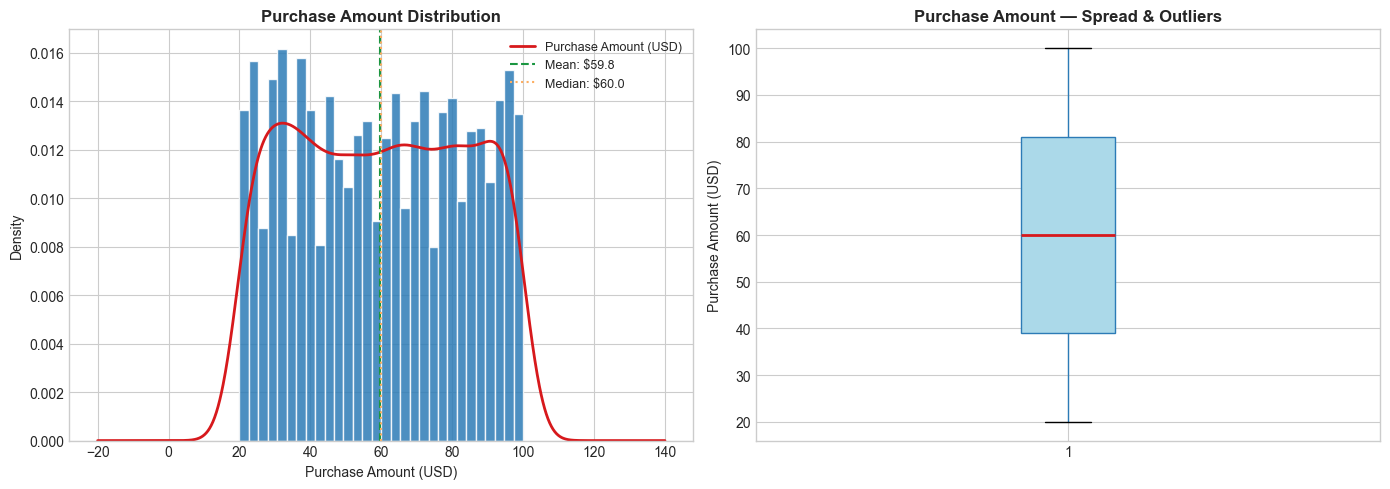

Skewness: 0.013
Kurtosis: -1.237
IQR: $42


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(df['Purchase Amount (USD)'], bins=30, color='#2C7BB6', edgecolor='white',
             alpha=0.85, density=True)
df['Purchase Amount (USD)'].plot(kind='kde', ax=axes[0], color='#D7191C', linewidth=2)
axes[0].set_title('Purchase Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Purchase Amount (USD)')
axes[0].set_ylabel('Density')
axes[0].axvline(df['Purchase Amount (USD)'].mean(), color='#1A9641', linestyle='--',
                linewidth=1.5, label=f'Mean: ${df["Purchase Amount (USD)"].mean():.1f}')
axes[0].axvline(df['Purchase Amount (USD)'].median(), color='#FDAE61', linestyle=':',
                linewidth=1.5, label=f'Median: ${df["Purchase Amount (USD)"].median():.1f}')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df['Purchase Amount (USD)'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#ABD9E9', color='#2C7BB6'),
                medianprops=dict(color='#D7191C', linewidth=2),
                whiskerprops=dict(color='#2C7BB6'),
                flierprops=dict(marker='o', markerfacecolor='#FDAE61', markersize=4, alpha=0.5))
axes[1].set_title('Purchase Amount — Spread & Outliers', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Purchase Amount (USD)')

plt.tight_layout()
plt.savefig('fig_purchase_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness: {df["Purchase Amount (USD)"].skew():.3f}')
print(f'Kurtosis: {df["Purchase Amount (USD)"].kurtosis():.3f}')
print(f'IQR: ${df["Purchase Amount (USD)"].quantile(0.75) - df["Purchase Amount (USD)"].quantile(0.25):.0f}')


**Interpretation:** Purchase Amount is fairly evenly distributed between $20–$100, with no strong concentration around a specific spending range. Customers appear to shop across different price points rather than clustering around only cheaper or premium products.

This suggests that customer value cannot be determined using purchase amount alone. A customer spending $90 once may not be as valuable as someone consistently making repeat purchases. Because of this, customer segmentation should consider both spending and purchase history together.


---
### Previous Purchases — Customer Tenure Proxy


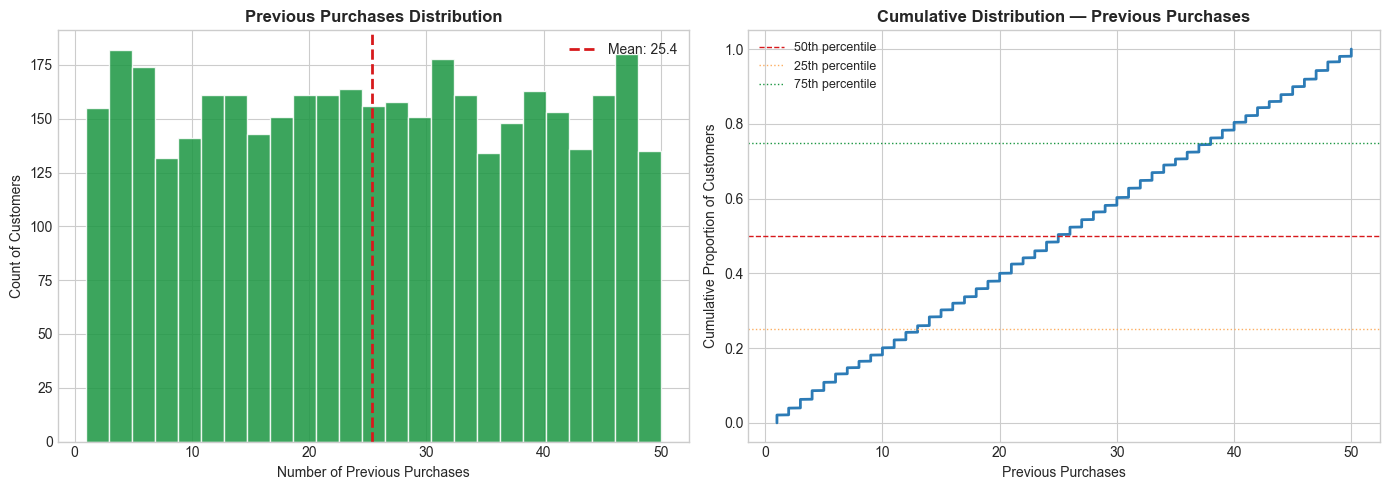

Mean previous purchases: 25.4
25th pct: 13
75th pct: 38


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Previous Purchases'], bins=25, color='#1A9641', edgecolor='white', alpha=0.85)
axes[0].set_title('Previous Purchases Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Previous Purchases')
axes[0].set_ylabel('Count of Customers')
axes[0].axvline(df['Previous Purchases'].mean(), color='#D7191C', linestyle='--',
                linewidth=2, label=f'Mean: {df["Previous Purchases"].mean():.1f}')
axes[0].legend()

# Cumulative distribution
sorted_pp = np.sort(df['Previous Purchases'])
axes[1].plot(sorted_pp, np.arange(1, len(sorted_pp)+1) / len(sorted_pp),
             color='#2C7BB6', linewidth=2)
axes[1].axhline(0.5, color='#D7191C', linestyle='--', linewidth=1, label='50th percentile')
axes[1].axhline(0.25, color='#FDAE61', linestyle=':', linewidth=1, label='25th percentile')
axes[1].axhline(0.75, color='#1A9641', linestyle=':', linewidth=1, label='75th percentile')
axes[1].set_title('Cumulative Distribution — Previous Purchases', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Previous Purchases')
axes[1].set_ylabel('Cumulative Proportion of Customers')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_previous_purchases_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean previous purchases: {df["Previous Purchases"].mean():.1f}')
print(f'25th pct: {df["Previous Purchases"].quantile(0.25):.0f}')
print(f'75th pct: {df["Previous Purchases"].quantile(0.75):.0f}')


**Interpretation:** Previous Purchases is fairly evenly spread across the full range of 1–50, with an average close to 25. This indicates that the dataset contains a healthy mix of both newer and more experienced customers, rather than being heavily skewed toward one group.

From an analytical perspective, this is useful because it allows customer tiers based on purchase history to be more balanced and meaningful.


---
### Review Rating Distribution 

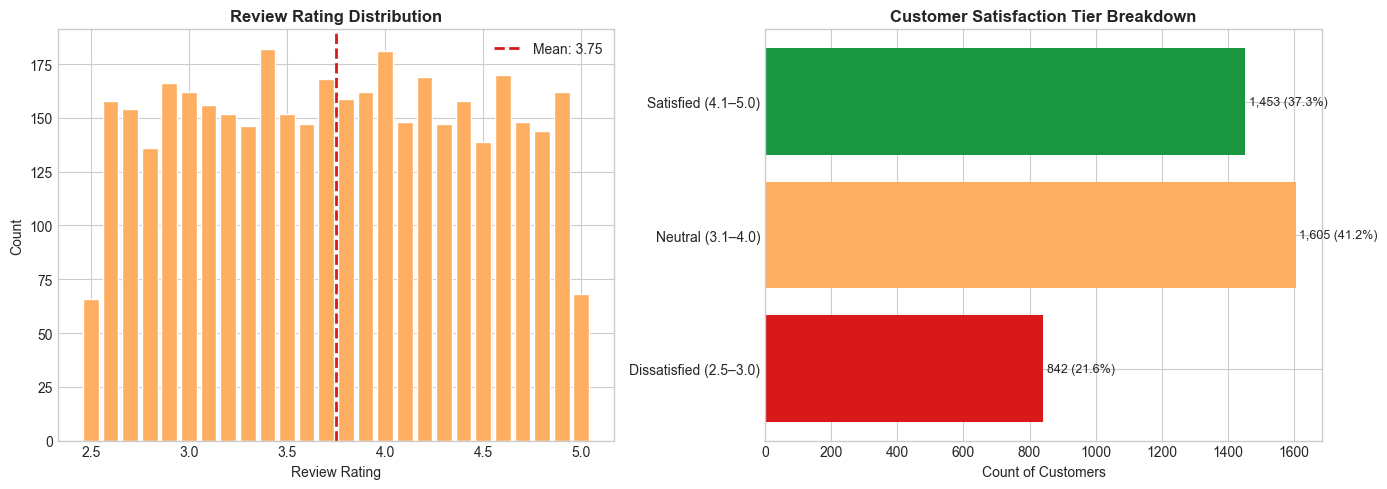

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = df['Review Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, width=0.08,
            color='#FDAE61', edgecolor='white')
axes[0].axvline(df['Review Rating'].mean(), color='#D7191C', linestyle='--',
                linewidth=2, label=f'Mean: {df["Review Rating"].mean():.2f}')
axes[0].set_title('Review Rating Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Review Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Segment by satisfaction tier
sat_tiers = pd.cut(df['Review Rating'],
                   bins=[2.4, 3.0, 4.0, 5.0],
                   labels=['Dissatisfied (2.5–3.0)', 'Neutral (3.1–4.0)', 'Satisfied (4.1–5.0)'])
sat_counts = sat_tiers.value_counts().sort_index()
colors_sat = ['#D7191C', '#FDAE61', '#1A9641']
axes[1].barh(sat_counts.index, sat_counts.values, color=colors_sat)
for i, (idx, val) in enumerate(sat_counts.items()):
    axes[1].text(val + 10, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
axes[1].set_title('Customer Satisfaction Tier Breakdown', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count of Customers')

plt.tight_layout()
plt.savefig('fig_review_rating_dist.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Review ratings are fairly evenly distributed between 2.5 and 5.0, without strong clustering at very high or very low values. In real-world customer feedback, ratings often tend to concentrate toward the extremes, so this distribution suggests that review scores may not strongly differentiate customer behavior in this dataset.

As a result, review rating should not be treated as a powerful standalone indicator of loyalty or customer quality. It can still contribute to loyalty scoring, but with lower importance compared to stronger behavioral signals like previous purchases or promotional dependency.


---
###  Promo Dependency — Checking what Fraction of the Base is Discount-Reliant?


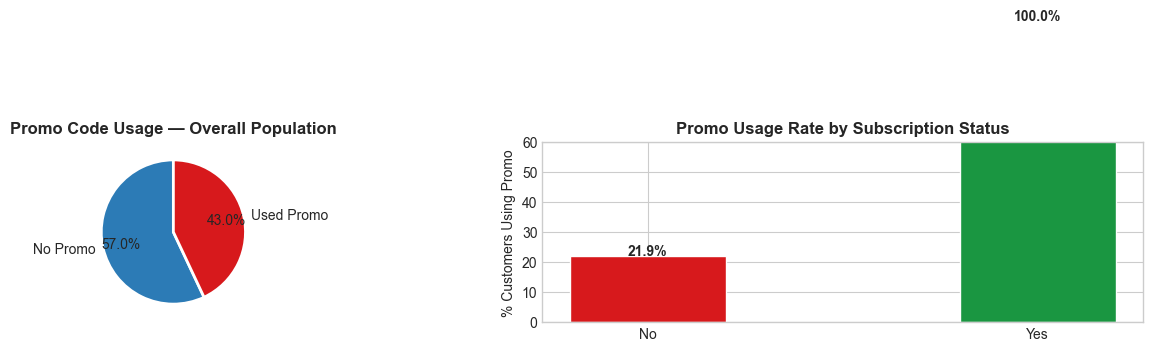

Promo usage rate by subscription status:
Subscription Status
No     21.900
Yes   100.000
Name: Promo_Code_Used_Enc, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Promo vs Non-Promo
promo_counts = df['Promo Code Used'].value_counts()
axes[0].pie(promo_counts.values, labels=['No Promo', 'Used Promo'],
            colors=['#2C7BB6', '#D7191C'], autopct='%1.1f%%',
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Promo Code Usage — Overall Population', fontsize=12, fontweight='bold')

# Promo usage by subscription status
promo_sub = df.groupby('Subscription Status')['Promo_Code_Used_Enc'].mean() * 100
bars = axes[1].bar(promo_sub.index, promo_sub.values,
                   color=['#D7191C', '#1A9641'], edgecolor='white', width=0.4)
for bar, val in zip(bars, promo_sub.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Promo Usage Rate by Subscription Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Customers Using Promo')
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.savefig('fig_promo_usage.png', dpi=150, bbox_inches='tight')
plt.show()

promo_rate_sub = df.groupby('Subscription Status')['Promo_Code_Used_Enc'].mean() * 100
print('Promo usage rate by subscription status:')
print(promo_rate_sub.round(1))


**Interpretation:** Around 43% of customers used a promo code, meaning a large portion of purchases are tied to discounts rather than purely organic demand. This suggests promotions play a major role in driving customer activity.

What stands out is that promo usage is fairly similar across both subscribers and non-subscribers. Ideally, a subscription or loyalty program should encourage customers to buy even without incentives. Since that difference is not very strong here, the subscription program may not yet be creating the kind of pricing power or long-term loyalty the brand would expect.


---
### Frequency of Purchase Distribution


In [20]:
df['Frequency of Purchases'] = df['Frequency of Purchases'].replace({
    'Bi-Weekly': 'Fortnightly',
    'Every 3 Months': 'Quarterly'
}, inplace= True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3441875971.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Frequency of Purchases'] = df['Frequency of Purchases'].replace({


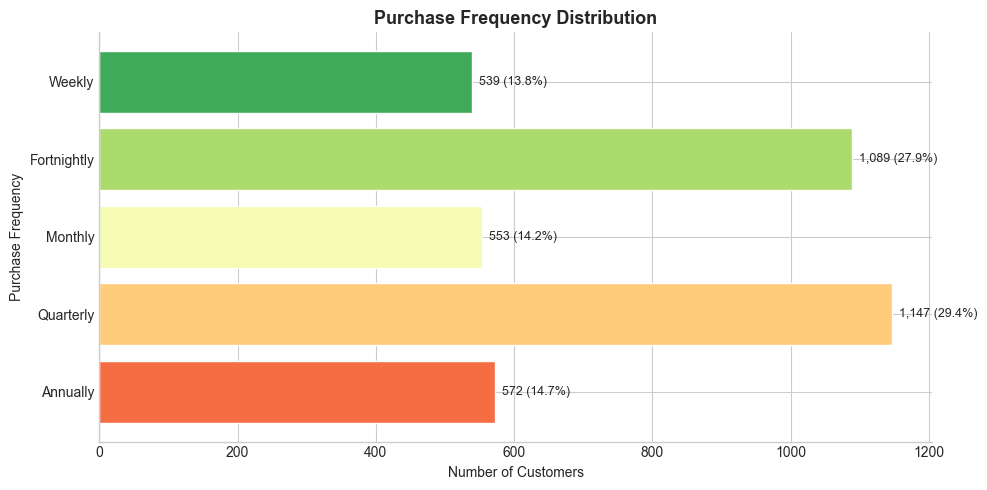

High-frequency customers: 2,181 (55.9%)


In [21]:
# Define logical purchase frequency order
freq_order = ['Annually', 'Quarterly', 'Monthly', 'Fortnightly', 'Weekly']

# Count customers in each category
freq_counts = (df['Frequency of Purchases'].value_counts().reindex(freq_order))

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Color palette
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(freq_order)))

# Horizontal bar chart
bars = ax.barh(freq_counts.index,freq_counts.values,color=colors,edgecolor='white')

# Add labels on bars
for bar, count in zip(bars, freq_counts.values):
    percentage = (count / len(df)) * 100
    
    ax.text(x=bar.get_width() + 10,y=bar.get_y() + bar.get_height() / 2,s=f'{count:,} ({percentage:.1f}%)',va='center',fontsize=9)

# Titles and labels
ax.set_title('Purchase Frequency Distribution',fontsize=13,fontweight='bold')

ax.set_xlabel('Number of Customers')
ax.set_ylabel('Purchase Frequency')

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

# High-frequency customer analysis
high_freq_customers = df[df['freq_score'] >= 5]

high_freq_pct = (len(high_freq_customers) / len(df)) * 100

print(
    f'High-frequency customers: '
    f'{len(high_freq_customers):,} '
    f'({high_freq_pct:.1f}%)'
)

**Interpretation:** Customer purchase frequency appears concentrated around the Fortnightly and Quarterly categories, which together account for more than half of the customer base. Weekly and Monthly purchase behaviors are comparatively smaller, while Annual customers form the lowest-engagement group.

This distribution suggests the business is not dominated by extremely high-frequency buyers. Instead, most customers interact with the brand at moderate intervals. From a retention perspective, the Fortnightly segment is especially valuable because it combines relatively frequent engagement with a large customer share.

At the same time, the sizeable Quarterly segment indicates that many customers may still view purchases as occasional rather than habit-driven. This creates an opportunity for the brand to increase engagement frequency through stronger retention and personalization strategies rather than relying heavily on discounts alone.


---
## Bivariate & Multivariate Analysis

This section examines *relationships* between variables — the interactions that reveal retention 
dynamics, promo behavior, and customer quality. Every analytical result here is interpreted not 
just for its statistical significance but for its *strategic implication*.


###  Promo Usage vs. Purchase Amount — Does Discounting Lift Spending?


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\4215780771.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(promo_groups, labels=['No Promo', 'Promo Used'],


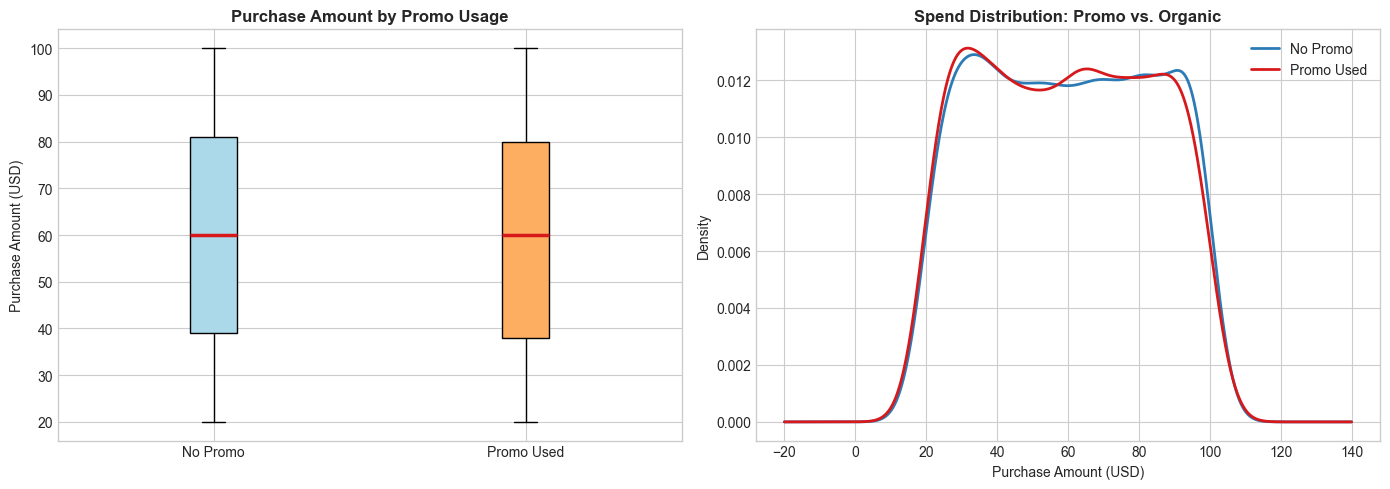

No Promo — Mean: $60.13, Median: $60.00
Promo Used — Mean: $59.28, Median: $60.00

Independent t-test: t=1.111, p=0.266


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
promo_groups = [df[df['Promo_Code_Used_Enc']==0]['Purchase Amount (USD)'],
                df[df['Promo_Code_Used_Enc']==1]['Purchase Amount (USD)']]
bp = axes[0].boxplot(promo_groups, labels=['No Promo', 'Promo Used'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#ABD9E9'),
                     medianprops=dict(color='#D7191C', linewidth=2.5))
bp['boxes'][1].set_facecolor('#FDAE61')
axes[0].set_title('Purchase Amount by Promo Usage', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Purchase Amount (USD)')

# KDE comparison
for grp, label, color in zip(promo_groups, ['No Promo', 'Promo Used'], ['#2C7BB6', '#D7191C']):
    grp.plot(kind='kde', ax=axes[1], label=label, color=color, linewidth=2)
axes[1].set_title('Spend Distribution: Promo vs. Organic', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Purchase Amount (USD)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_promo_vs_spend.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
no_promo = df[df['Promo_Code_Used_Enc']==0]['Purchase Amount (USD)']
with_promo = df[df['Promo_Code_Used_Enc']==1]['Purchase Amount (USD)']
t_stat, p_val = stats.ttest_ind(no_promo, with_promo)

print(f'No Promo — Mean: ${no_promo.mean():.2f}, Median: ${no_promo.median():.2f}')
print(f'Promo Used — Mean: ${with_promo.mean():.2f}, Median: ${with_promo.median():.2f}')
print(f'\nIndependent t-test: t={t_stat:.3f}, p={p_val:.3f}')


**Interpretation:** Promo users and non-promo users show fairly similar average purchase amounts, suggesting that discounts are not significantly increasing how much customers spend per transaction.

This is an important signal because it raises the possibility that promotions may be reducing margins without meaningfully increasing customer value. In other words, many customers using discounts might have purchased anyway, just at a lower effective price.

At this stage, the findings do not necessarily mean promotions are ineffective, but they do suggest the brand should examine whether discounts are driving long-term repeat behavior or simply encouraging short-term price-sensitive purchases.


---
###  Previous Purchases vs. Promo Usage — Who Are the Repeat Buyers?


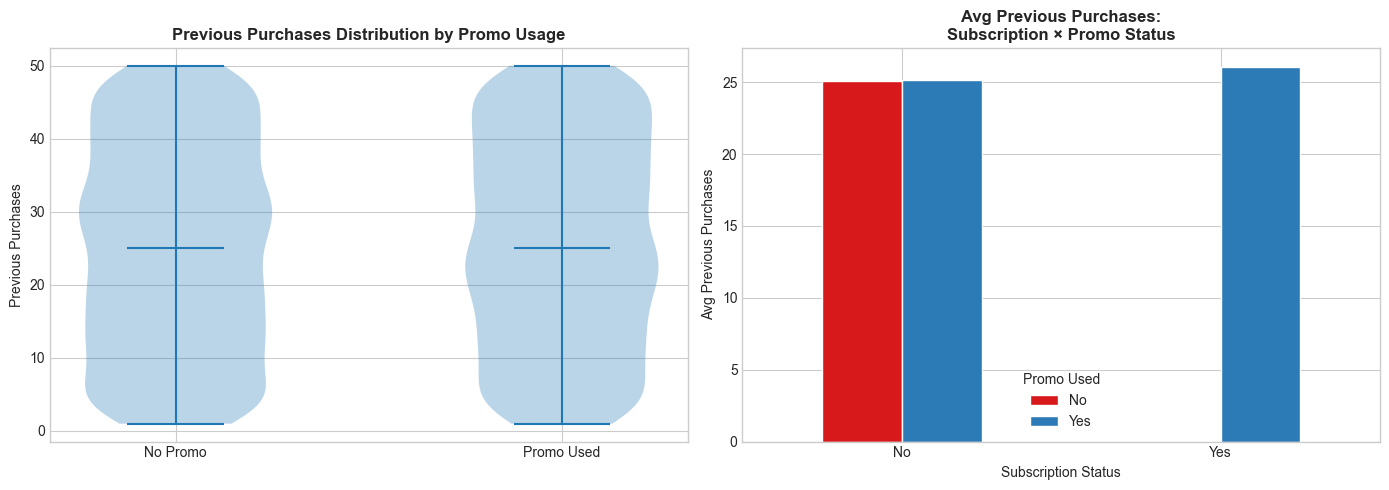

Avg previous purchases by promo usage:
Promo Code Used
No    25.060
Yes   25.740
Name: Previous Purchases, dtype: float64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previous purchases by promo
pp_no_promo = df[df['Promo_Code_Used_Enc']==0]['Previous Purchases']
pp_promo    = df[df['Promo_Code_Used_Enc']==1]['Previous Purchases']

axes[0].violinplot([pp_no_promo, pp_promo], positions=[1, 2], showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['No Promo', 'Promo Used'])
axes[0].set_title('Previous Purchases Distribution by Promo Usage', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Previous Purchases')

# Avg previous purchases by subscription + promo combination
combo = df.groupby(['Subscription Status', 'Promo Code Used'])['Previous Purchases'].mean().unstack()
combo.plot(kind='bar', ax=axes[1], color=['#D7191C', '#2C7BB6'], edgecolor='white', width=0.5)
axes[1].set_title('Avg Previous Purchases:\nSubscription × Promo Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Subscription Status')
axes[1].set_ylabel('Avg Previous Purchases')
axes[1].legend(title='Promo Used', labels=['No', 'Yes'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig_prev_purchases_promo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avg previous purchases by promo usage:')
print(df.groupby('Promo Code Used')['Previous Purchases'].mean().round(2))


**Interpretation:** Customers using promo codes show similar, and in some cases slightly higher, previous purchase counts compared to non-promo customers. This suggests that discount usage is not limited to newer or occasional buyers — even long-term customers appear to rely on promotions.

This is strategically important because it indicates that promotional behavior may already be deeply embedded within the customer base. Reducing discounts too aggressively could risk affecting customers who have strong purchase history with the brand.

Instead of removing promotions broadly, the business may need a more gradual and targeted approach that differentiates between genuinely price-sensitive customers and those likely to continue purchasing without heavy incentives.


---
###  Category vs. Purchase Behavior & Tenure


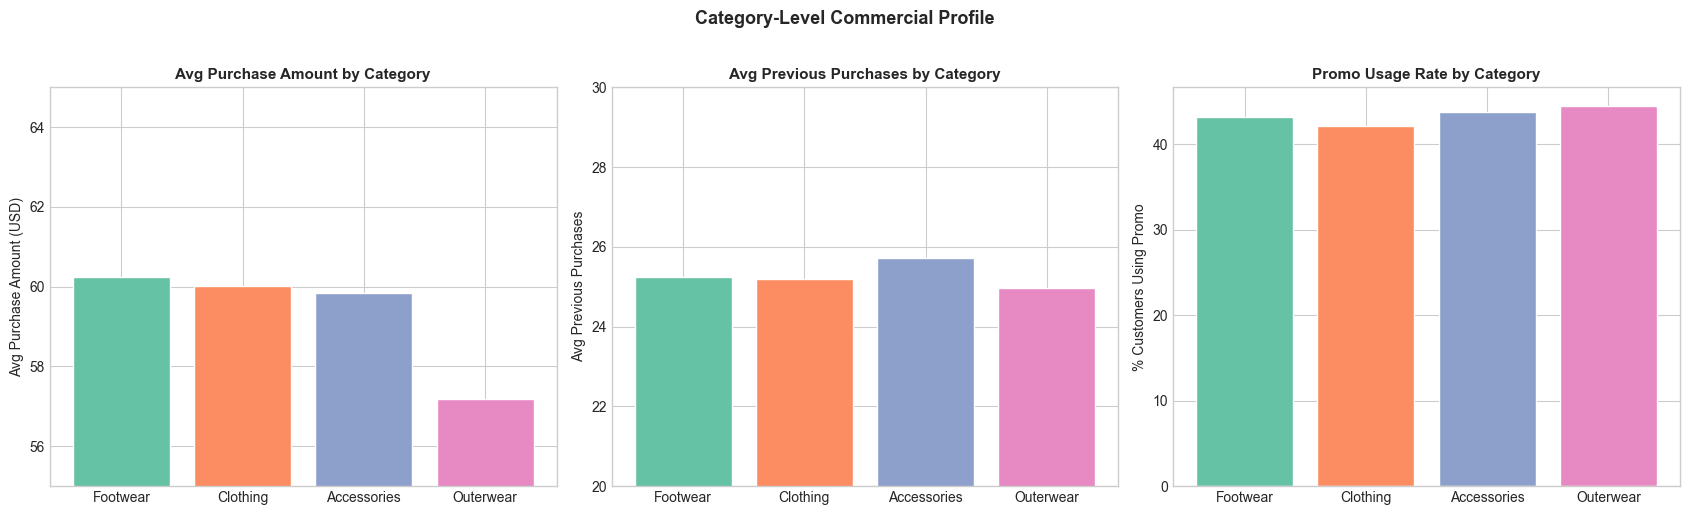

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cat_order = df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False).index

# Avg spend by category
cat_spend = df.groupby('Category')['Purchase Amount (USD)'].mean().reindex(cat_order)
axes[0].bar(cat_spend.index, cat_spend.values, color=PALETTE_CAT[:4], edgecolor='white')
axes[0].set_title('Avg Purchase Amount by Category', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Avg Purchase Amount (USD)')
axes[0].set_ylim(55, 65)

# Avg previous purchases by category
cat_pp = df.groupby('Category')['Previous Purchases'].mean().reindex(cat_order)
axes[1].bar(cat_pp.index, cat_pp.values, color=PALETTE_CAT[:4], edgecolor='white')
axes[1].set_title('Avg Previous Purchases by Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg Previous Purchases')
axes[1].set_ylim(20, 30)

# Promo rate by category
cat_promo = df.groupby('Category')['Promo_Code_Used_Enc'].mean().reindex(cat_order) * 100
axes[2].bar(cat_promo.index, cat_promo.values, color=PALETTE_CAT[:4], edgecolor='white')
axes[2].set_title('Promo Usage Rate by Category', fontsize=11, fontweight='bold')
axes[2].set_ylabel('% Customers Using Promo')

plt.suptitle('Category-Level Commercial Profile', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Spending patterns across the product categories are fairly similar, meaning no single category stands out as the clear revenue driver on its own. However, differences begin to appear when looking at promo usage and previous purchase behavior together.

Some categories show higher promo dependency along with lower purchase history, suggesting they may act as entry points for attracting newer customers. Other categories show stronger repeat purchase behavior and lower reliance on discounts, indicating they are more closely associated with loyal or long-term customers.

From a business perspective, this distinction matters. Discounting can be more useful in entry-level categories where the goal is customer acquisition, but applying heavy promotions in retention-oriented categories could unnecessarily reduce margins from customers who may already be willing to purchase without incentives.


---
###  Subscription Status vs. Commercial Value


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\718234565.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(sub_data, labels=['Not Subscribed', 'Subscribed'],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\718234565.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(sub_data, labels=['Not Subscribed', 'Subscribed'],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\718234565.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(sub_data, labels=['Not Subscribed', 'Subscribed'],


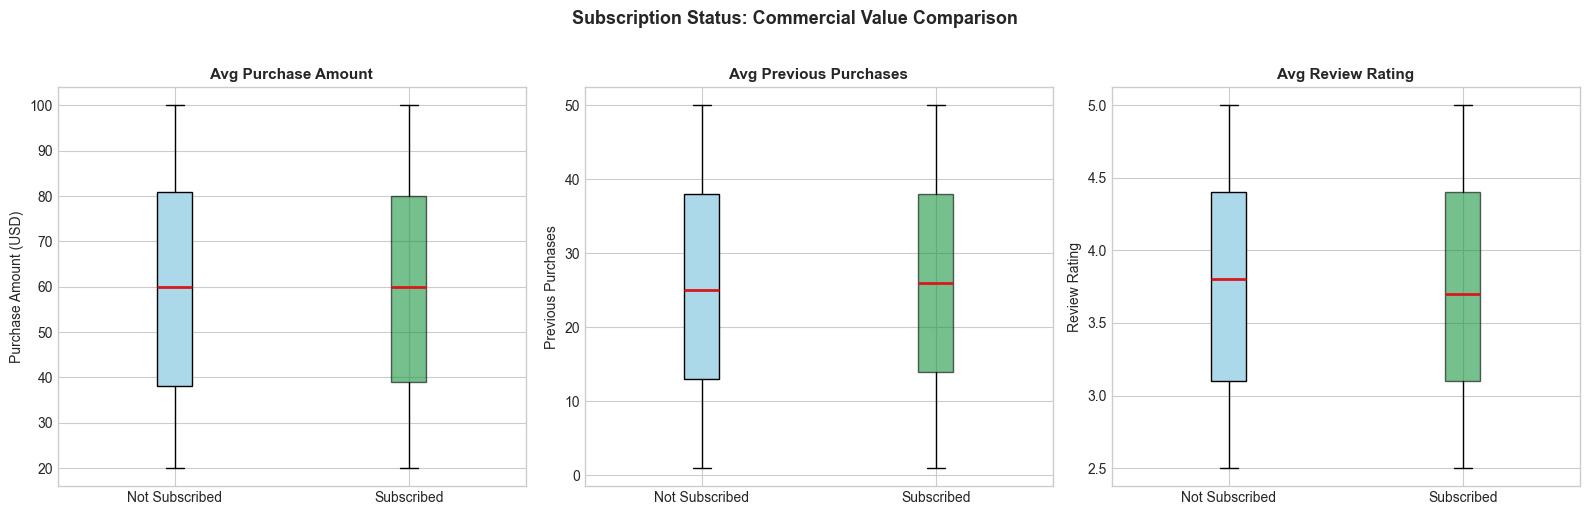

Mean values by subscription status:
                     Purchase Amount (USD)  Previous Purchases  Review Rating
Subscription Status                                                          
No                                  59.870              25.080          3.750
Yes                                 59.490              26.080          3.750


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Purchase Amount (USD)', 'Previous Purchases', 'Review Rating']
titles  = ['Avg Purchase Amount', 'Avg Previous Purchases', 'Avg Review Rating']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sub_data = [df[df['Subscription Status']=='No'][metric],
                df[df['Subscription Status']=='Yes'][metric]]
    bp = axes[i].boxplot(sub_data, labels=['Not Subscribed', 'Subscribed'],
                         patch_artist=True,
                         boxprops=dict(facecolor='#ABD9E9'),
                         medianprops=dict(color='#D7191C', linewidth=2))
    bp['boxes'][1].set_facecolor('#1A9641')
    bp['boxes'][1].set_alpha(0.6)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_ylabel(metric)

plt.suptitle('Subscription Status: Commercial Value Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_subscription_value.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean values by subscription status:')
print(df.groupby('Subscription Status')[metrics].mean().round(2))


**Interpretation:** Subscription status shows only moderate differences across spending and engagement metrics. Subscribed customers do not appear to spend substantially more or purchase significantly more frequently than non-subscribers.

This raises an important business question about the actual effectiveness of the subscription program. At the moment, subscriptions may be acting more as an indicator of already-engaged customers rather than actively increasing customer value or retention.

In other words, customers who subscribe may already be loyal before joining the program. If that is the case, the brand may need to rethink the benefits offered through subscriptions so they create stronger incentives for repeat purchasing and long-term engagement.


---
### Correlation Matrix — Key Numeric Relationships


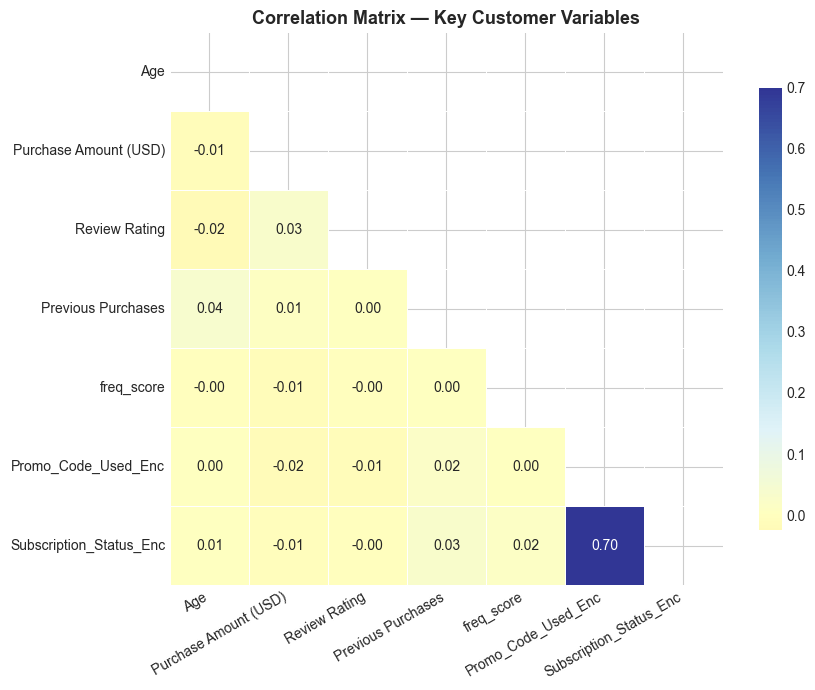

In [26]:
corr_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating',
             'Previous Purchases', 'freq_score', 'Promo_Code_Used_Enc', 'Subscription_Status_Enc']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Customer Variables', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The correlation matrix shows that most variables have relatively weak linear relationships with each other. There are no major multicollinearity concerns, but there is also no single feature that strongly explains customer value or loyalty on its own.

This is an important finding because it suggests customer behavior in this dataset is influenced by multiple factors simultaneously rather than one dominant metric. Spending, purchase history, satisfaction, and promotional behavior each capture different aspects of the customer relationship.

As a result, relying on any single variable would oversimplify the problem. This supports the need for engineered composite metrics that combine several behavioral and commercial signals into more meaningful loyalty and retention indicators.


---
### Geographic Analysis — Revenue and Promo Dependency by State


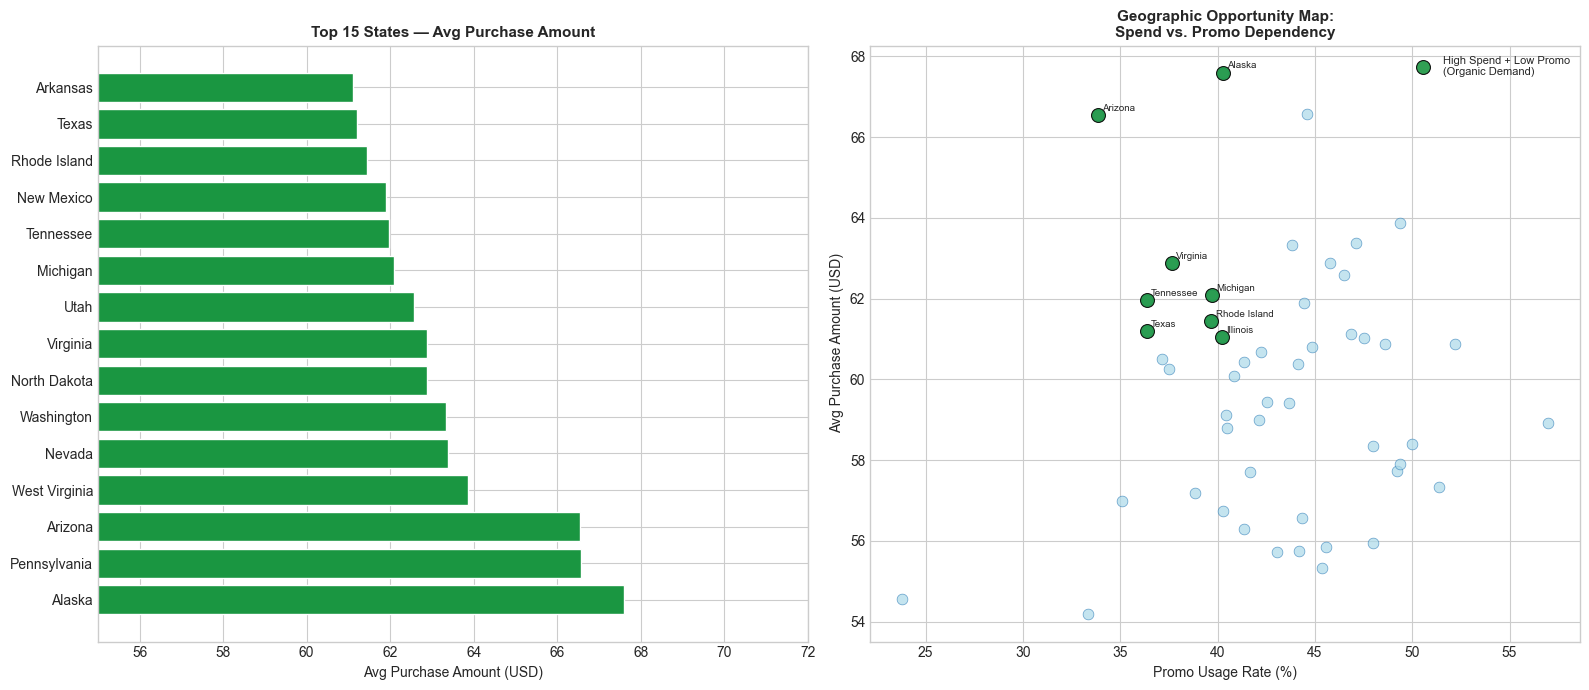

Top organic demand states (high spend, low promo):
        Location  avg_spend  promo_rate_pct  customer_count
1         Alaska     67.597          40.278              72
2        Arizona     66.554          33.846              65
45      Virginia     62.883          37.662              77
21      Michigan     62.096          39.726              73
41     Tennessee     61.974          36.364              77
38  Rhode Island     61.444          39.683              63
42         Texas     61.195          36.364              77
12      Illinois     61.054          40.217              92


In [27]:
geo_agg = df.groupby('Location').agg(
    avg_spend=('Purchase Amount (USD)', 'mean'),
    promo_rate=('Promo_Code_Used_Enc', 'mean'),
    avg_prev_purchases=('Previous Purchases', 'mean'),
    customer_count=('Customer ID', 'count')
).reset_index()
geo_agg['promo_rate_pct'] = geo_agg['promo_rate'] * 100

# Top 15 and bottom 15 by avg spend
top15 = geo_agg.nlargest(15, 'avg_spend')
bot15 = geo_agg.nsmallest(15, 'avg_spend')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# High spenders
axes[0].barh(top15['Location'], top15['avg_spend'], color='#1A9641', edgecolor='white')
axes[0].set_title('Top 15 States — Avg Purchase Amount', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Avg Purchase Amount (USD)')
axes[0].set_xlim(55, 72)

# Highlight: high spend + low promo = organic demand
organic = geo_agg[(geo_agg['avg_spend'] > geo_agg['avg_spend'].quantile(0.67)) &
                  (geo_agg['promo_rate'] < geo_agg['promo_rate'].quantile(0.33))]

axes[1].scatter(geo_agg['promo_rate_pct'], geo_agg['avg_spend'],
                c='#ABD9E9', edgecolors='#2C7BB6', s=60, alpha=0.7, linewidth=0.5)
axes[1].scatter(organic['promo_rate_pct'], organic['avg_spend'],
                c='#1A9641', edgecolors='black', s=100, alpha=0.9, linewidth=0.8,
                label='High Spend + Low Promo\n(Organic Demand)')
for _, row in organic.iterrows():
    axes[1].annotate(row['Location'], (row['promo_rate_pct'], row['avg_spend']),
                     fontsize=7, xytext=(3, 3), textcoords='offset points')
axes[1].set_title('Geographic Opportunity Map:\nSpend vs. Promo Dependency', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Promo Usage Rate (%)')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top organic demand states (high spend, low promo):')
print(organic[['Location', 'avg_spend', 'promo_rate_pct', 'customer_count']].sort_values('avg_spend', ascending=False).to_string())


**Interpretation:** The geographic analysis highlights clear differences in customer behavior across states. Some regions show relatively high spending along with low promo usage, suggesting that customers in these markets are willing to purchase without relying heavily on discounts. These are likely the brand’s strongest markets in terms of organic demand and customer-brand alignment.

On the other hand, some states show lower spending combined with higher promotional dependency. In these markets, discounts appear to play a larger role in driving purchases, which may indicate weaker pricing power or lower brand affinity.

This distinction is strategically important because the same marketing approach should not be applied everywhere. Markets with strong organic demand may benefit more from premium positioning and retention-focused strategies, while highly discount-sensitive regions may require a different acquisition and engagement approach.


---
###  Age vs. Spending & Promo Behavior


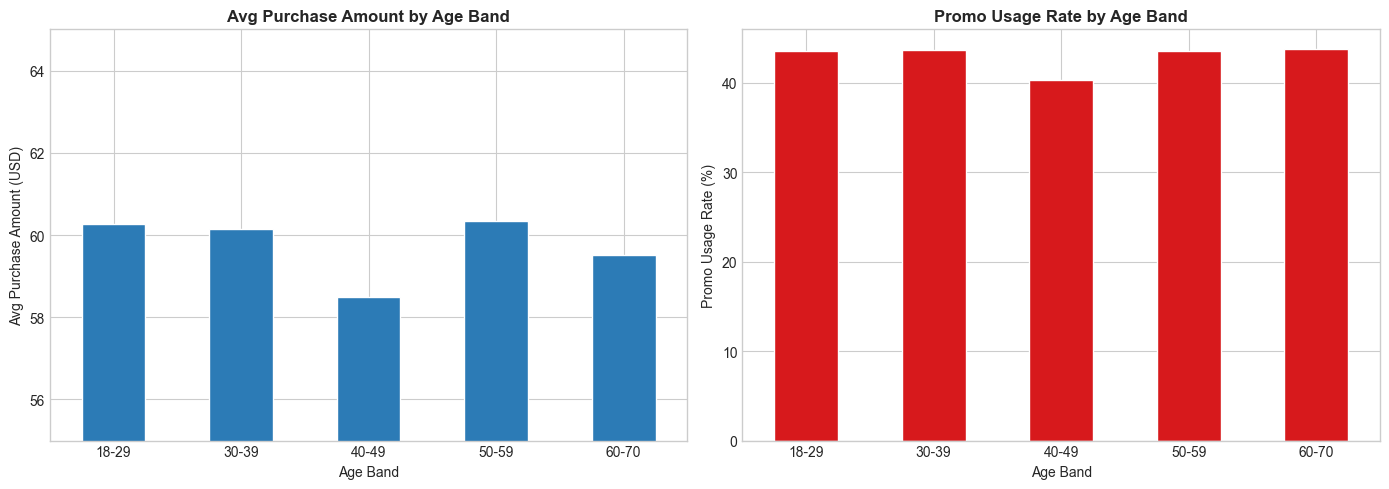

In [28]:
df['age_band'] = pd.cut(df['Age'], bins=[17, 29, 39, 49, 59, 70],
                         labels=['18-29', '30-39', '40-49', '50-59', '60-70'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_spend = df.groupby('age_band', observed=True)['Purchase Amount (USD)'].mean()
age_promo = df.groupby('age_band', observed=True)['Promo_Code_Used_Enc'].mean() * 100

age_spend.plot(kind='bar', ax=axes[0], color='#2C7BB6', edgecolor='white')
axes[0].set_title('Avg Purchase Amount by Age Band', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Avg Purchase Amount (USD)')
axes[0].set_ylim(55, 65)
axes[0].tick_params(axis='x', rotation=0)

age_promo.plot(kind='bar', ax=axes[1], color='#D7191C', edgecolor='white')
axes[1].set_title('Promo Usage Rate by Age Band', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Promo Usage Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Age shows modest variation in spending and promo behavior across bands. 
No single age cohort dramatically dominates on either metric, suggesting the brand has broad 
demographic appeal rather than being concentrated in a niche age segment. 
This is a commercially healthy signal — it reduces concentration risk — but also means 
demographic targeting alone will not unlock differentiated retention strategy. 
Behavioral signals (promo usage, subscription, purchase history) are more discriminating than age.


---
##  Feature Engineering

The guiding principle: **every engineered feature must answer a question the brand actually cares about.** 
Features that are mathematically interesting but commercially ambiguous have no place here.

We are not adding numbers for the sake of complexity. Here are the eight features and the questions they serve:

| # | Feature | Business Question |
|---|---------|-------------------|
| 2 | Lifetime Value Score | How valuable is this customer based on volume, spend, and previous history? |
| 3 | Lifetime Value Tier | Which value segment does this customer fall into? |
| 4 | Satisfaction Flag | Is this customer an advocate, neutral, or a churn risk? |
| 5 | Loyalty Classification | Is this customer truly loyal, or just discount-trained? |
| 6 | Purchase Urgency Score | How urgently does this customer need their products? |
| 7 | Customer Archetype | How do subscription and promo usage intersect to define cohorts? |
| 8 | Brand Commitment Score | What is the overall strength of their unconditional commitment? |

---


In [29]:
scaler = MinMaxScaler()

# Normalize numerics needed for scoring
df['prev_norm']   = scaler.fit_transform(df[['Previous Purchases']])
df['spend_norm']  = scaler.fit_transform(df[['Purchase Amount (USD)']])
df['rating_norm'] = scaler.fit_transform(df[['Review Rating']])
df['freq_norm']   = scaler.fit_transform(df[['freq_score']])

print('Normalization complete. All features scaled to [0, 1].')


Normalization complete. All features scaled to [0, 1].


---
###  Lifetime Value Score
 We need a composite metric to rank customers. Without revenue-over-time data, we use three available proxies:

- **Previous Purchases (40%):** Strongest signal of historical commitment. A customer with 50 prior purchases has demonstrated loyalty beyond any single transaction.
- **Purchase Frequency (35%):** Signals recurring behavior. High-frequency buyers form the habitual base.
- **Purchase Amount (25%):** Captures basket size but is given lower weight because a one-time big spender may not be a loyal customer.

All three components are min-max normalized to [0,1] before weighting.

`lifetime_val_score = (Nomralized Previous Purchases)*0.4 + (Normalized Frequency Score) * 0.35 + (Normalized Purchase Amount (USD))*0.25 `

In [30]:
df['lifetime_val_score'] = (
    0.40 * df['prev_norm'] +
    0.35 * df['freq_norm'] +
    0.25 * df['spend_norm']
).round(4)

print('Customer Value Score stats:')
print(df['lifetime_val_score'].describe())

Customer Value Score stats:
count   3900.000
mean       0.436
std        0.181
min        0.018
25%        0.304
50%        0.428
75%        0.558
max        0.997
Name: lifetime_val_score, dtype: float64


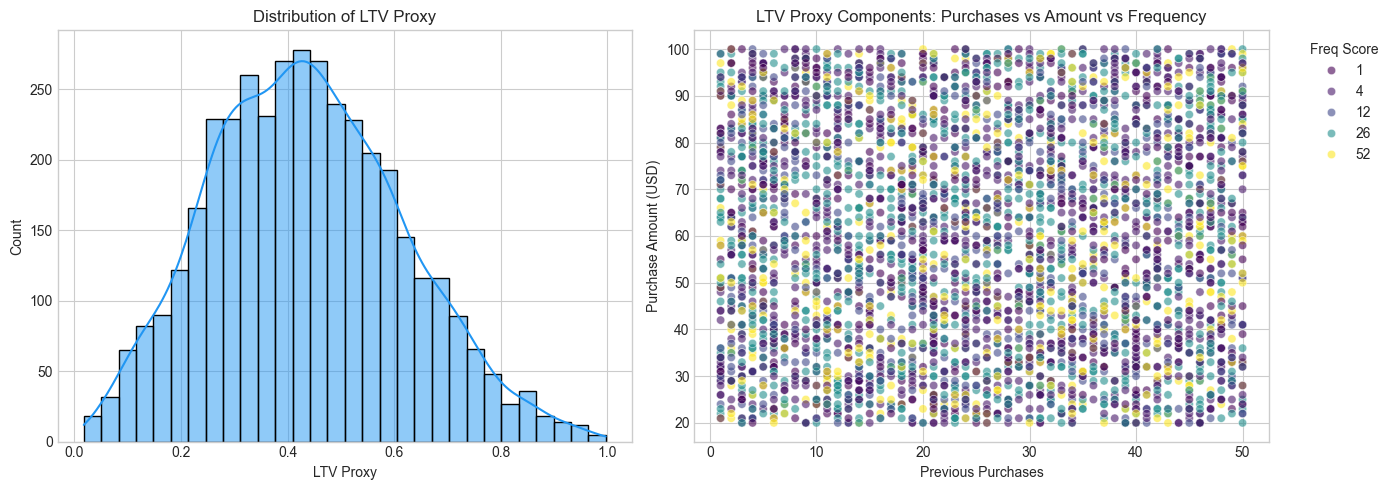

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale (distribution is heavily right-skewed)
sns.histplot(df['lifetime_val_score'], bins=30, kde=True, ax=axes[0], color='#2196F3')
axes[0].set_title('Distribution of LTV Proxy')
axes[0].set_xlabel('LTV Proxy')
axes[0].set_ylabel('Count')

# Scatterplot showing the three components
scatter = sns.scatterplot(
    data=df, x='Previous Purchases', y='Purchase Amount (USD)',
    hue='freq_score', palette='viridis', alpha=0.6, ax=axes[1]
)
axes[1].set_title('LTV Proxy Components: Purchases vs Amount vs Frequency')
axes[1].set_xlabel('Previous Purchases')
axes[1].set_ylabel('Purchase Amount (USD)')
axes[1].legend(title='Freq Score', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---
###  Lifetime Value Tier

| Tier | Meaning |
|------|---------|
| **High** | Top 25% — highest value, most likely to be loyal core |
| **Normal**    | Second quantile — strong potential, may respond to loyalty nudges |
| **Low**     | Third quantile — moderate engagement, needs nurturing |
| **Risk**     | Bottom 25% — new, infrequent, or bargain-only buyers |

Value Tier distribution:
lifetime_value_tier
Risk      975
Low       975
Normal    975
High      975
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3004207842.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lifetime_value_tier', y='Purchase Amount (USD)', order=tier_order, ax=ax, palette=PALETTE_MAIN)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3004207842.py:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(data=df, x='lifetime_value_tier', y='Purchase Amount (USD)', order=tier_order, ax=ax, palette=PALETTE_MAIN)


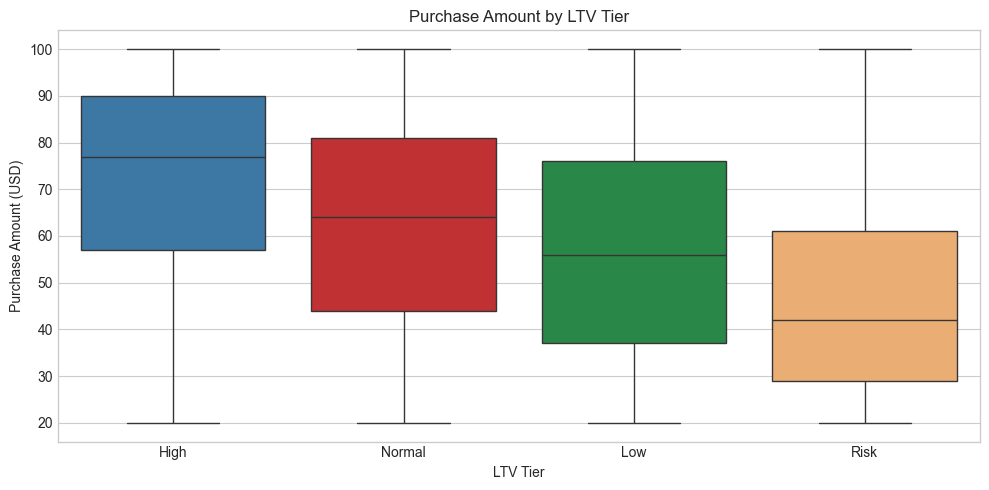

In [32]:
df['lifetime_value_tier'] = pd.qcut(df['lifetime_val_score'],q=4,labels=['Risk', 'Low', 'Normal', 'High'])

print('Value Tier distribution:')
print(df['lifetime_value_tier'].value_counts().sort_index())
tier_order = ['High', 'Normal', 'Low', 'Risk']
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x='lifetime_value_tier', y='Purchase Amount (USD)', order=tier_order, ax=ax, palette=PALETTE_MAIN)
ax.set_title('Purchase Amount by LTV Tier')
ax.set_xlabel('LTV Tier')
ax.set_ylabel('Purchase Amount (USD)')

plt.tight_layout()
plt.show()

Each tier has roughly the same number of customers (~975), confirming that qcut worked as intended. The boxplot shows that Champions do tend to have higher purchase amounts, but the differences are not dramatic. This makes sense because LTV Proxy is also driven by frequency and tenure, not just spend alone.


---
###  Satisfaction Flag
Review rating is the only available satisfaction proxy. Customers above this threshold are more likely to recommend, return, and tolerate full-price purchases.
Using the cleaned (imputed) Review Rating, apply these thresholds:

  `Satisfied    = Rating >= 4.0   → flag value 1`
  
  `Neutral      = 3.0 <= Rating < 4.0  → flag value 0`
  
  `Dissatisfied = Rating < 3.0   → flag value -1`

Store as Satisfaction_Flag (integer: 1, 0, -1) and Satisfaction_Label (string: "Satisfied", "Neutral", "Dissatisfied")

**What it captures:** Qualitative signal of brand affinity. Combining this with purchase behavior helps us distinguish *engaged* high-value customers from *transactional* ones.

In [33]:
def get_satisfaction(rating):
    if rating >= 4.0:
        return 1
    elif rating >= 3.0:
        return 0
    else:
        return -1

def get_satisfaction_label(rating):
    if rating >= 4.0:
        return "Satisfied"
    elif rating >= 3.0:
        return "Neutral"
    else:
        return "Dissatisfied"

if 'Satisfaction_Flag' in df.columns:
    df.drop(columns=['Satisfaction_Flag', 'Satisfaction_Label'], inplace=True, errors='ignore')

df['Satisfaction_Flag'] = df['Review Rating'].apply(get_satisfaction)
df['Satisfaction_Label'] = df['Review Rating'].apply(get_satisfaction_label)


In [34]:
sat_agg = df.groupby('Satisfaction_Label').agg(
    count=('Customer ID', 'count'),
    mean_prev_purchases=('Previous Purchases', 'mean'),
    mean_ltv=('lifetime_val_score', 'mean')
).reset_index()

sat_agg['pct'] = (sat_agg['count'] / len(df)) * 100

# Format the table for display
sat_styled = sat_agg.style.format({
    'mean_prev_purchases': '${:.2f}',
    'mean_ltv': '{:,.2f}',
    'pct': '{:.1f}%'
}).set_caption("Customer Satisfaction Tiers").hide(axis='index')

display(sat_styled)


Satisfaction_Label,count,mean_prev_purchases,mean_ltv,pct
Dissatisfied,680,$25.05,0.43,17.4%
Neutral,1586,$25.39,0.44,40.7%
Satisfied,1634,$25.44,0.44,41.9%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3616839790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Satisfaction_Label', order=label_order, palette=colors)


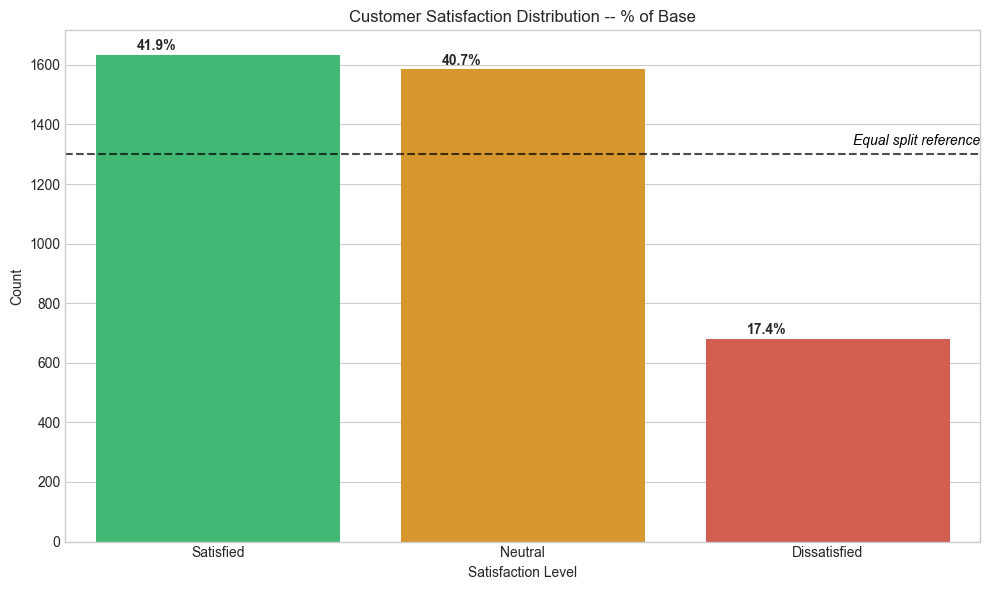

In [35]:
label_order = ['Satisfied', 'Neutral', 'Dissatisfied']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Satisfaction_Label', order=label_order, palette=colors)

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2 - 0.2
    y = p.get_height() + 15
    ax.annotate(percentage, (x, y), ha='center', weight='bold')

# Reference line at 33%
ref_val = total * 0.3333
ax.axhline(ref_val, color='black', linestyle='--', alpha=0.7)
ax.text(2.5, ref_val + 20, 'Equal split reference', ha='right', va='bottom', color='black', style='italic')

ax.set_title('Customer Satisfaction Distribution -- % of Base')
ax.set_xlabel('Satisfaction Level')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


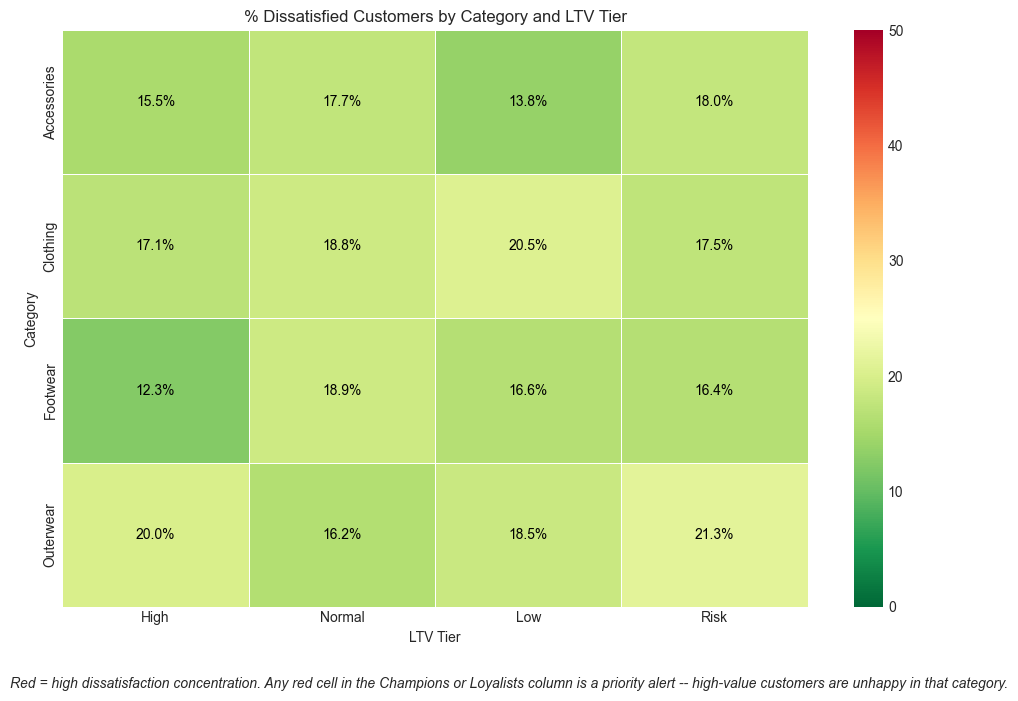

In [36]:
def pct_dissatisfied(x):
    return (sum(x == -1) / len(x)) * 100 if len(x) > 0 else 0

pivot_sat = df.pivot_table(index='Category', columns='lifetime_value_tier', values='Satisfaction_Flag', aggfunc=pct_dissatisfied)
tier_order = ['High', 'Normal', 'Low', 'Risk']
pivot_sat = pivot_sat[tier_order]

plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    pivot_sat,
    annot=False,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=50,
    linewidths=.5
)

# Manually add annotations with '%'
for i in range(pivot_sat.shape[0]):
    for j in range(pivot_sat.shape[1]):
        val = pivot_sat.iloc[i, j]
        ax.text(j+0.5, i+0.5, f"{val:.1f}%", ha='center', va='center', color='black')

ax.set_title('% Dissatisfied Customers by Category and LTV Tier')
ax.set_xlabel('LTV Tier')
ax.set_ylabel('Category')

# Note below the plot
plt.figtext(0.5, 0.01, "Red = high dissatisfaction concentration. Any red cell in the Champions or Loyalists column is a priority alert -- high-value customers are unhappy in that category.", ha="center", fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


####  Interpretation of the heatmap

1. **Most alarming cell:** The most critical finding is **21.3%** of **Outerwear** customers in the **Risk** segment are dissatisfied. This is the brand's highest-priority product or experience issue.

2. **High Value-column pattern:** Looking only at the High Value column, **Outerwear** has the highest dissatisfaction (**20%**) among top-value customers. Losing a High Value-tier customer costs the brand disproportionately more than losing an At-Risk customer.

3. **Uniformly high dissatisfaction:** **Clothing** has uniformly high dissatisfaction across all tiers (ranging from **17.1%** to **20.5%**). This indicates a product-level structural problem, not a value-tier-specific one.

4. **Uniformly low dissatisfaction:** **Footwear** shows the lowest dissatisfaction overall, with Footwear High Value having the lowest dissatisfaction rate on the board at **12.3**. This indicates this is the brand's strongest product line and should be used as a retention anchor.


---
###  Customer Profile (2x2 Subscription × Promo)

By crossing `Subscription Status` with `Promo Dependency Score`, we create a 2x2 grid representing four customer archetypes:

- **Loyal Subscribers**: Subscribers who do NOT rely on promos (Sub=1, Promo =0)
- **Discount Subscriber**: Subscribers heavily reliant on promos (Sub=1, Promo = 1)
- **Loyal NonSubscribers**: Non-subscribers who buy without promos (Sub=0, Promo =0)
- **Discount NonSubsribers**: Non-subscribers who rely on promos (Sub=0, Promo = 1)


In [37]:
# Create behavioral profile using subscription engagement
# and promotional dependency

conditions = [
    (df['Subscription_Status_Enc'] == 1) & (df['Promo_Code_Used_Enc'] < 0.5),
    
    (df['Subscription_Status_Enc'] == 1) & (df['Promo_Code_Used_Enc'] >= 0.5),
    
    (df['Subscription_Status_Enc'] == 0) & (df['Promo_Code_Used_Enc'] < 0.5),
    
    (df['Subscription_Status_Enc'] == 0) & (df['Promo_Code_Used_Enc'] >= 0.5)
]

profile_labels = [
    'Loyal Subscribers',
    'Discount Subscriber',
    'Loyal NonSubscribers',
    'Discount NonSubsribers'
]

df['Customer_Behavior_Profile'] = np.select(
    conditions,
    profile_labels,
    default='Unclassified'
)



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3066097297.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3066097297.py:24: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3066097297.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3066097297.py:43: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(


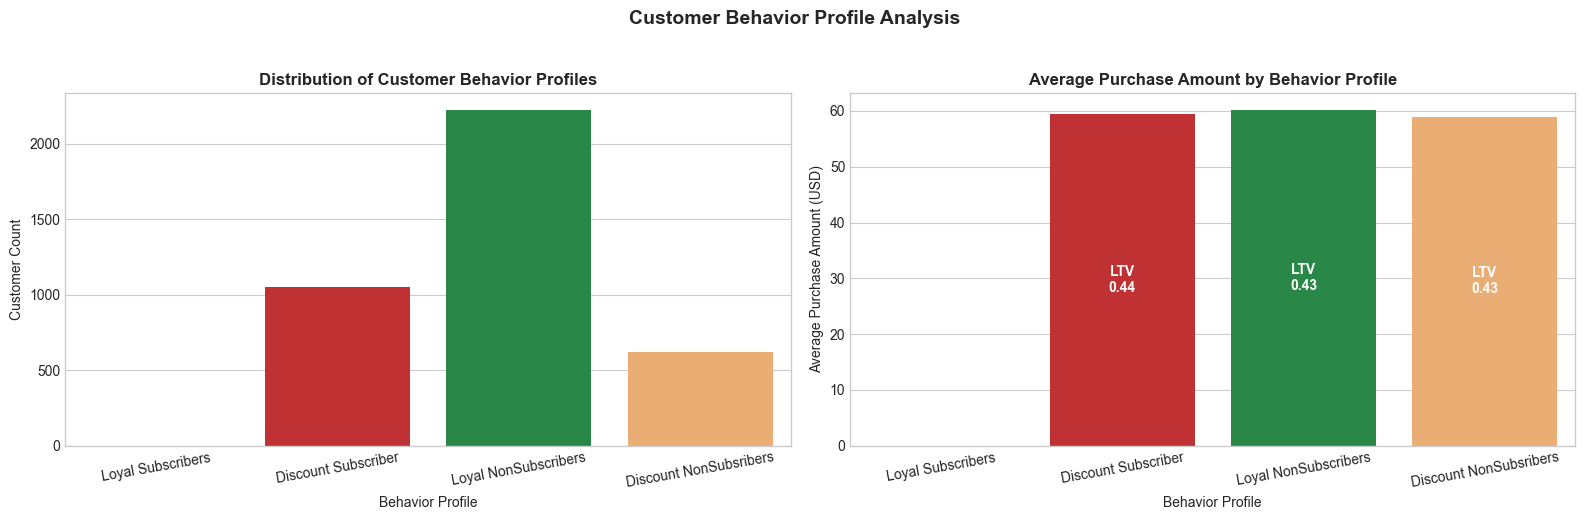

,Customer_Behavior_Profile,customer_count,avg_ltv_proxy,avg_purchase_amount,avg_previous_purchases,avg_review_rating
0,Loyal Subscribers,NaN,NaN,NaN,NaN,NaN
1,Discount Subscriber,1053.000,0.440,59.490,26.080,3.750
2,Loyal NonSubscribers,2223.000,0.430,60.130,25.060,3.760
3,Discount NonSubsribers,624.000,0.430,58.920,25.170,3.730


In [38]:
profile_order = [
    'Loyal Subscribers',
    'Discount Subscriber',
    'Loyal NonSubscribers',
    'Discount NonSubsribers'
]

# Aggregate metrics
profile_summary = (
    df.groupby('Customer_Behavior_Profile')
    .agg(
        customer_count=('Customer ID', 'count'),
        avg_ltv_proxy=('lifetime_val_score', 'mean'),
        avg_purchase_amount=('Purchase Amount (USD)', 'mean'),
        avg_previous_purchases=('Previous Purchases', 'mean'),
        avg_review_rating=('Review Rating', 'mean')
    )
    .reindex(profile_order)
    .reset_index()
)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(
    data=df,
    x='Customer_Behavior_Profile',
    order=profile_order,
    palette=PALETTE_MAIN,
    ax=axes[0]
)

axes[0].set_title(
    'Distribution of Customer Behavior Profiles',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Behavior Profile')
axes[0].set_ylabel('Customer Count')

axes[0].tick_params(axis='x', rotation=10)

sns.barplot(
    data=profile_summary,
    x='Customer_Behavior_Profile',
    y='avg_purchase_amount',
    palette=PALETTE_MAIN,
    ax=axes[1]
)

for i, row in enumerate(profile_summary.itertuples()):

    axes[1].text(
        x=i,
        y=row.avg_purchase_amount / 2,
        s=f'LTV\n{row.avg_ltv_proxy:.2f}',
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

axes[1].set_title(
    'Average Purchase Amount by Behavior Profile',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Behavior Profile')
axes[1].set_ylabel('Average Purchase Amount (USD)')

axes[1].tick_params(axis='x', rotation=10)

plt.suptitle(
    'Customer Behavior Profile Analysis',
    fontsize=14,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()
display(profile_summary.round(2))

**Strategic Interpretation:**

One of the most striking findings from this framework is that the dataset contains virtually no subscribers with no promotional dependency. In practice, this means nearly all subscribed customers still rely heavily on discounts when purchasing.

This raises important questions about the effectiveness of the subscription program. Rather than creating stronger pricing power or brand attachment, the program may currently be reinforcing promotional behavior instead.

The most promising customer group appears to be the Organic Non-Subscribers. These customers already purchase with relatively low dependence on discounts, indicating stronger natural willingness to pay full price. Instead of targeting them with additional price reductions, the brand could position subscriptions around convenience, early access, premium experiences, or exclusivity.

On the other hand, Promo-Dependent Subscribers represent the most delicate segment from a retention perspective. Their engagement with the brand appears closely tied to financial incentives, meaning an aggressive reduction in discounts could negatively impact retention if handled too abruptly. Any promotional restructuring strategy should therefore be gradual and segment-specific rather than broad-based.


---
### Purchase Urgency Score

We map `Shipping Type` to a 0-4 numerical scale indicating purchase urgency. 

- `Next Day Air` → 4
- `Express` → 3
- `2-Day Shipping` → 2
- `Standard` → 1
- `Free Shipping` → 0
- `Store Pickup` → -1 (Flagged as an anomaly, since it implies a physical presence which contradicts the D2C strictly online premise, or at least requires separate local operations).

This urgency score will help us quantify how quickly customers need their products and check if high-LTV customers behave more urgently.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\2781116500.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=urgency_tier, x='lifetime_value_tier', y='Urgency_Score', palette=PALETTE_MAIN, ax=axes[1])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\2781116500.py:25: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=urgency_tier, x='lifetime_value_tier', y='Urgency_Score', palette=PALETTE_MAIN, ax=axes[1])


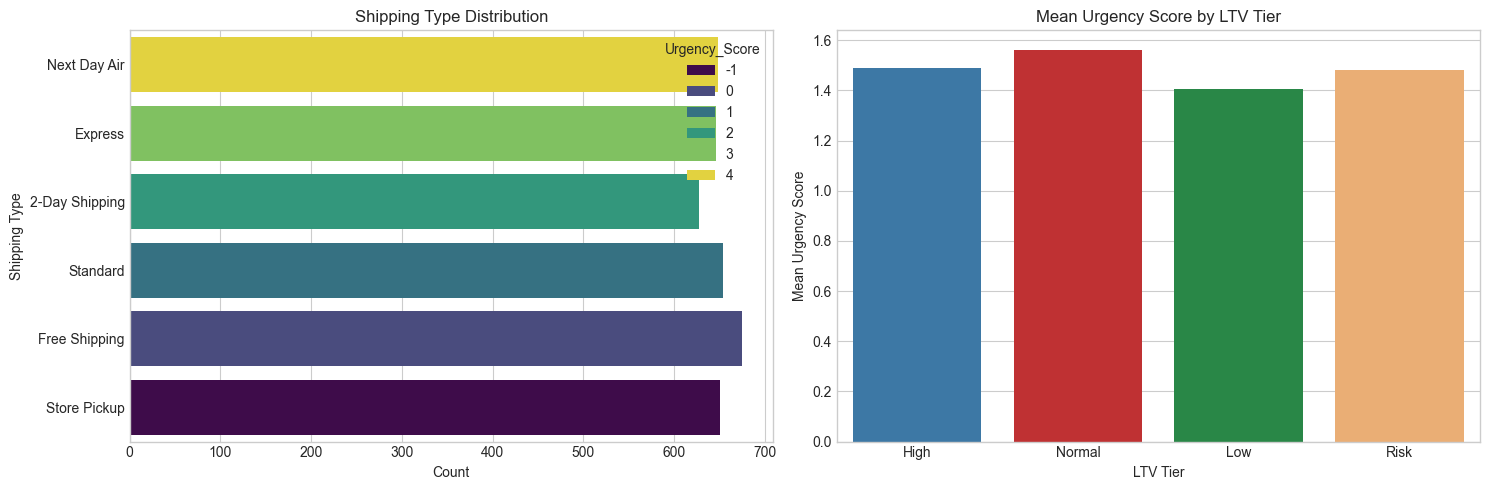

In [39]:
urgency_map = {
    'Next Day Air': 4,
    'Express': 3,
    '2-Day Shipping': 2,
    'Standard': 1,
    'Free Shipping': 0,
    'Store Pickup': -1
}
df['Urgency_Score'] = df['Shipping Type'].map(urgency_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Countplot
sns.countplot(
    data=df, y='Shipping Type', hue='Urgency_Score',
    order=['Next Day Air', 'Express', '2-Day Shipping', 'Standard', 'Free Shipping', 'Store Pickup'],
    palette='viridis', ax=axes[0]
)
axes[0].set_title('Shipping Type Distribution')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Shipping Type')

# Mean urgency by LTV Tier
urgency_tier = df.groupby('lifetime_value_tier')['Urgency_Score'].mean().reindex(tier_order).reset_index()
sns.barplot(data=urgency_tier, x='lifetime_value_tier', y='Urgency_Score', palette=PALETTE_MAIN, ax=axes[1])
axes[1].set_title('Mean Urgency Score by LTV Tier')
axes[1].set_xlabel('LTV Tier')
axes[1].set_ylabel('Mean Urgency Score')

plt.tight_layout()
plt.show()


---
### The Dual Loyalty Framework

**Why two loyalty definitions are necessary:**

Loyalty is not a single construct. In the absence of longitudinal behavioral data, loyalty can only 
be *inferred* — and different inference strategies capture different dimensions of it.

Two distinct operationalizations are needed for three reasons:

1. **No ground truth exists**: Without observed repeat purchase sequences or churn events, no single 
definition can be validated against a true outcome. Multiple definitions provide internal 
cross-validation.
2. **Loyalty is multi-dimensional**: A customer who has purchased 40 times but always needs a promo 
code is loyal in a *behavioral* sense but commercially fragile. A customer who spends \$90 at full 
price is commercially loyal but may be a recent entrant with low tenure. These are meaningfully different.

3. **Strategic decisions depend on which dimension you optimize for**: Retention strategy, discount 
sunset plans, and marketing targeting all depend on which customers you define as 'worth protecting'. 
Competing frameworks force rigor in that definition.



--- 
**Loyalty Definition A — Behavioral Engagement Loyalty:**

A customer is loyal if they have above-median previous purchases AND a monthly-or-higher purchase frequency (Frequency_Score >= 12). This captures customers who engage often.

**Loyalty Definition B - Commercial Loyalty (Margin_Loyalty)**

A customer is loyal if they have above-median previous purchases AND a Promo Dependency Score of 0. This captures customers who keep buying without needing to be incentivized.

The key disagreement cell to watch is where Behavioral = 1 but Margin = 0. These are high-frequency buyers who always use a promo. They look loyal by volume metrics, but they may be eroding margins.



Median Previous Purchases: 25.0

Crosstab: Behavioral vs Margin Loyalty
is_loyal_commercial     0     1   All
is_loyal_behavioral                  
0                    2320   494  2814
1                     477   609  1086
All                  2797  1103  3900

Detailed Segment Profiles:


,is_loyal_behavioral,is_loyal_commercial,count,mean_ltv,mean_purchase,mean_rating,mean_sub
0,0,0,2320,0.350,59.634,3.743,0.315
1,0,1,494,0.443,60.781,3.761,0.000
2,1,0,477,0.618,58.210,3.720,0.675
3,1,1,609,0.615,60.654,3.792,0.000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3876951596.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Segment', y='mean_ltv', palette=PALETTE_MAIN)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\3876951596.py:31: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=plot_data, x='Segment', y='mean_ltv', palette=PALETTE_MAIN)


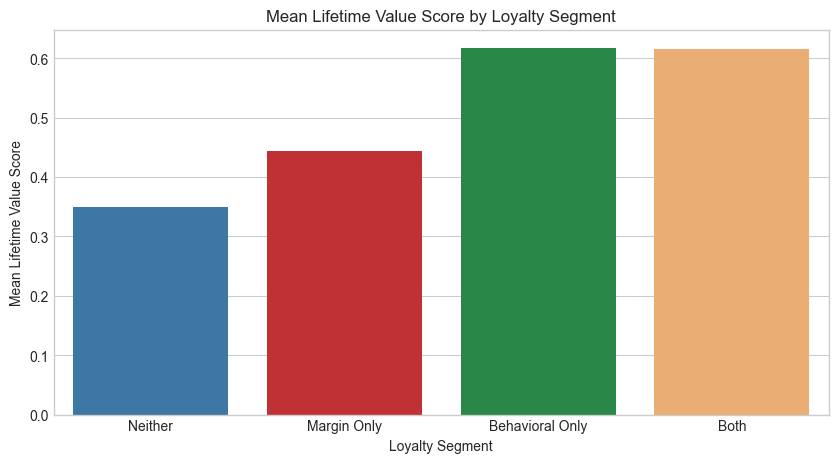

In [40]:
med_purchases = df['Previous Purchases'].median()
print(f"Median Previous Purchases: {med_purchases}")

# Definition 1: Behavioral Loyalty
df['is_loyal_behavioral'] = np.where(
    (df['Previous Purchases'] > med_purchases) & (df['freq_score'] >= 12), 1, 0)
# Definition 2: Margin Loyalty
df['is_loyal_commercial'] = np.where((df['Previous Purchases'] > med_purchases) & (df['Discount_Applied_Enc'] == 0), 1, 0)

# Crosstab
print("\nCrosstab: Behavioral vs Margin Loyalty")
print(pd.crosstab(df['is_loyal_behavioral'], df['is_loyal_commercial'], margins=True))

# Detailed analysis for each of the 4 cells
crosstab_analysis = df.groupby(['is_loyal_behavioral', 'is_loyal_commercial']).agg(
    count=('Customer ID', 'count'),
    mean_ltv=('lifetime_val_score', 'mean'),
    mean_purchase=('Purchase Amount (USD)', 'mean'),
    mean_rating=('Review Rating', 'mean'),
    mean_sub=('Subscription_Status_Enc', 'mean')
).reset_index()

print("\nDetailed Segment Profiles:")
display(crosstab_analysis)

# Grouped bar chart
plot_data = crosstab_analysis.copy()
plot_data['Segment'] = ['Neither', 'Margin Only', 'Behavioral Only', 'Both']

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x='Segment', y='mean_ltv', palette=PALETTE_MAIN)
plt.title('Mean Lifetime Value Score by Loyalty Segment')
plt.xlabel('Loyalty Segment')
plt.ylabel('Mean Lifetime Value Score')
plt.show()


**Key finding from the loyalty comparison:**

The most important insight emerges from the *“Behavioral Only”* segment — customers who purchase frequently but still rely heavily on promotions. This group records a mean purchase amount of $58.21 and an average review rating of 3.72, both slightly lower than the “Margin Only” segment ($60.78 and 3.76) and the “Both” segment ($60.65 and 3.79).

The Behavioral Only segment also shows a notably high subscription rate of 67.5%, suggesting that many of these customers may remain engaged because they continue receiving promotional incentives tied to the subscription program.

Taken together, these patterns make the **Behavioral Loyalty** framework more convincing as a measure of genuine customer loyalty. 
While both frameworks identify higher-value customers than the baseline population, the Behavioral Loyalty framework is selected as the primary definition because it is built on observable engagement signals rather than purchasing conditions. Loyalty, by definition, implies an ongoing relationship with the brand, and in the absence of timestamps or churn labels, repeat purchase history and purchase frequency provide the most direct evidence of that relationship. Although the Commercial Loyalty framework captures pricing independence, it is better interpreted as a measure of customer quality rather than loyalty itself. Therefore, Behavioral Loyalty is used as the core loyalty construct, while Commercial Loyalty is retained as a complementary diagnostic lens for understanding promotional dependency.


---
##  Customer Segmentation

Using Loyalty A as the primary scoring framework, combined with promo dependency as an independent 
diagnostic dimension, five commercially meaningful customer segments are constructed. 
Each segment is defined by a specific combination of loyalty score and promo behavior — ensuring 
that every label is **traceable to a combination of variables**, not asserted intuitively.


In [41]:
# Segment construction — rule-based using loyalty_a and promo_binary
# Loyalty thresholds: Q75 for 'high loyalty', Q50 for 'mid loyalty'
la_q50 = df['is_loyal_behavioral'].quantile(0.50)
la_q75 = df['is_loyal_behavioral'].quantile(0.75)

conditions = [
    (df['is_loyal_behavioral'] >= la_q75) & (df['Promo_Code_Used_Enc'] == 0),             # High loyalty, organic
    (df['is_loyal_behavioral'] >= la_q75) & (df['Promo_Code_Used_Enc'] == 1),             # High loyalty, promo-reliant
    (df['is_loyal_behavioral'] >= la_q50) & (df['is_loyal_behavioral'] < la_q75) & (df['Promo_Code_Used_Enc'] == 0),  # Mid loyalty, organic
    (df['is_loyal_behavioral'] >= la_q50) & (df['is_loyal_behavioral'] < la_q75) & (df['Promo_Code_Used_Enc'] == 1),  # Mid loyalty, promo
    (df['is_loyal_behavioral'] < la_q50),                                           # Low loyalty
]

seg_labels = [
    'Premium Loyalists',        # High loyalty, no promo — ideal customers
    'Growth Customers',         # High engagement but promo-conditioned — convertible
    'Organic High-Value',       # Mid loyalty, buy clean — underrecognized segment
    'Promo-Driven Buyers',      # Mid loyalty, promo-dependent — highest risk
    'At-Risk / Low Engagement'  # Low loyalty — retention or churn candidates
]

df['segment'] = np.select(conditions, seg_labels, default='At-Risk / Low Engagement')

seg_counts = df['segment'].value_counts()
print('Segment Distribution:')
print(seg_counts)
print(f'\nTotal customers: {len(df):,}')


Segment Distribution:
segment
Organic High-Value     1614
Promo-Driven Buyers    1200
Premium Loyalists       609
Growth Customers        477
Name: count, dtype: int64

Total customers: 3,900


In [42]:
# Full segment profile
seg_profile = df.groupby('segment').agg(
    n_customers       = ('Customer ID', 'count'),
    avg_purchase      = ('Purchase Amount (USD)', 'mean'),
    avg_prev_purchases= ('Previous Purchases', 'mean'),
    avg_loyalty_a     = ('is_loyal_behavioral', 'mean'),
    promo_rate        = ('Promo_Code_Used_Enc', 'mean'),
    sub_rate          = ('Subscription_Status_Enc', 'mean'),
    avg_rating        = ('Review Rating', 'mean'),
).round(3)
seg_profile['revenue_share_pct'] = (seg_profile['n_customers'] * seg_profile['avg_purchase'] /
                                     (seg_profile['n_customers'] * seg_profile['avg_purchase']).sum() * 100).round(1)
seg_profile = seg_profile.sort_values('avg_loyalty_a', ascending=False)

print('Segment Profile — Ordered by Avg Loyalty Score:')
print(seg_profile.to_string())


Segment Profile — Ordered by Avg Loyalty Score:
                     n_customers  avg_purchase  avg_prev_purchases  avg_loyalty_a  promo_rate  sub_rate  avg_rating  revenue_share_pct
segment                                                                                                                               
Growth Customers             477        58.210              38.044          1.000       1.000     0.675       3.720             11.900
Premium Loyalists            609        60.654              37.409          1.000       0.000     0.000       3.792             15.800
Organic High-Value          1614        59.933              20.395          0.000       0.000     0.000       3.745             41.500
Promo-Driven Buyers         1200        59.704              20.853          0.000       1.000     0.609       3.748             30.700


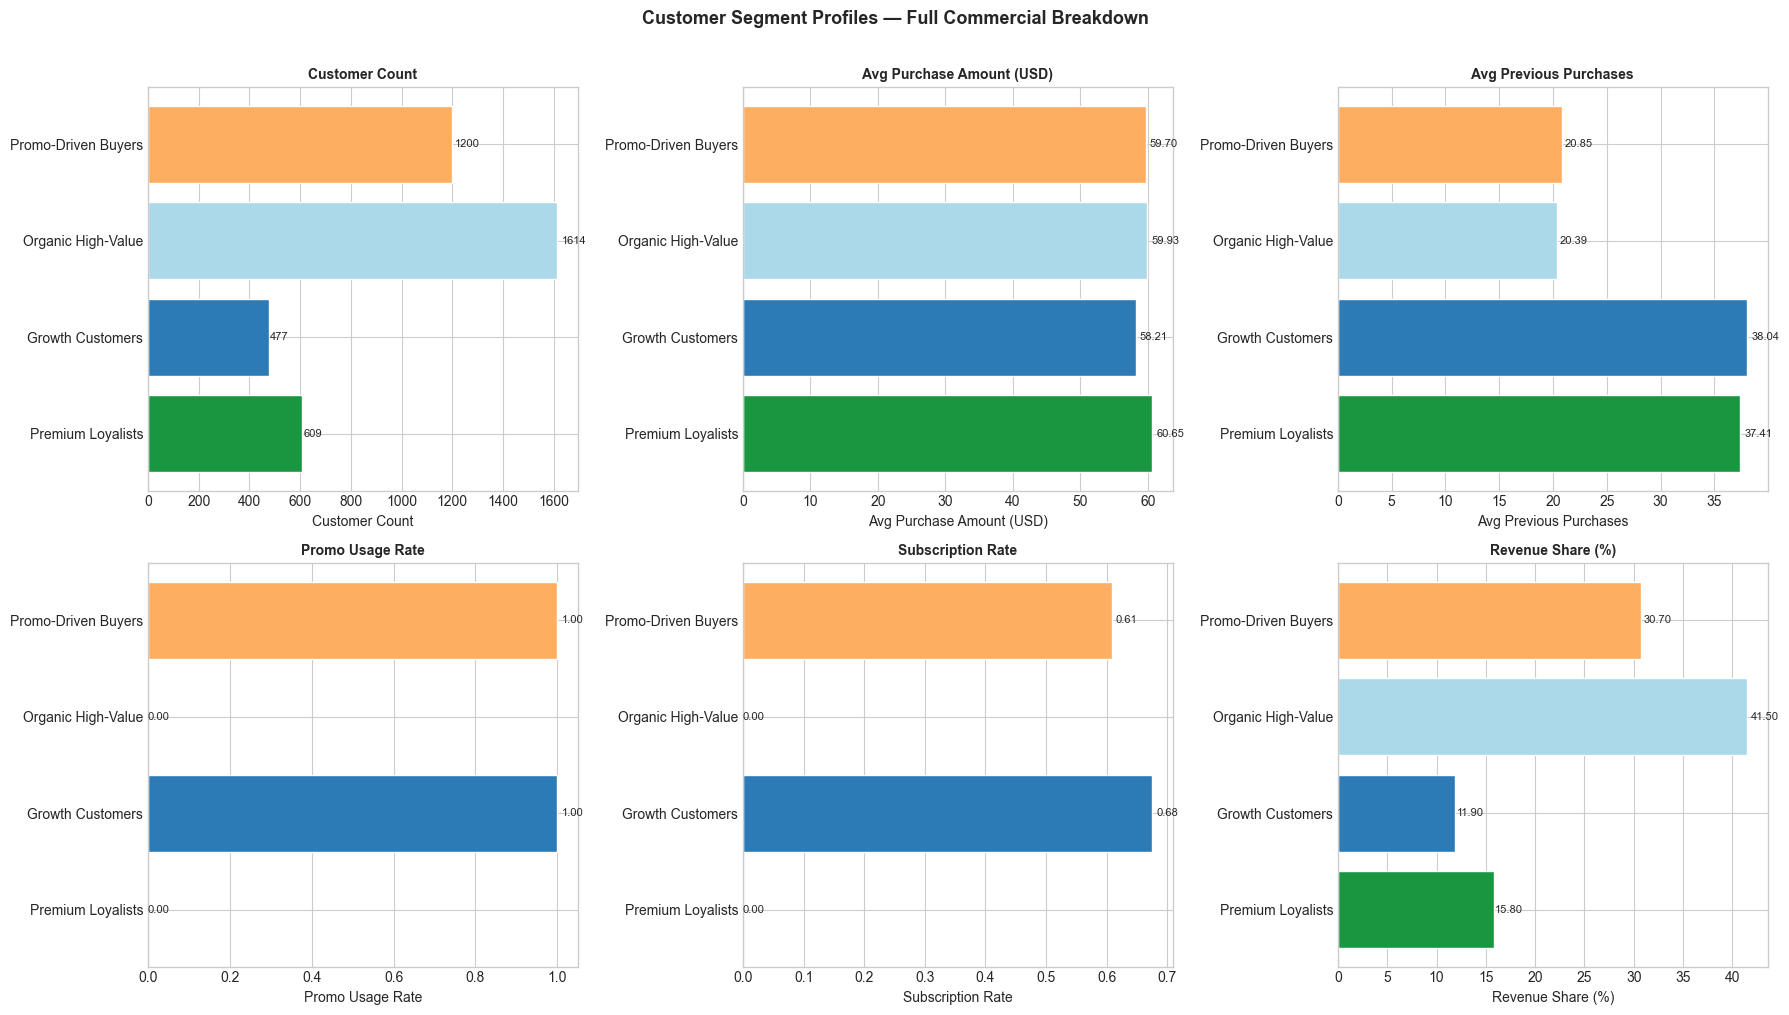

In [43]:
seg_order = ['Premium Loyalists', 'Growth Customers', 'Organic High-Value',
             'Promo-Driven Buyers', 'At-Risk / Low Engagement']
seg_colors = ['#1A9641', '#2C7BB6', '#ABD9E9', '#FDAE61', '#D7191C']
color_map  = dict(zip(seg_order, seg_colors))

seg_profile_ordered = seg_profile.reindex(seg_order)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_metrics = [
    ('n_customers', 'Customer Count'),
    ('avg_purchase', 'Avg Purchase Amount (USD)'),
    ('avg_prev_purchases', 'Avg Previous Purchases'),
    ('promo_rate', 'Promo Usage Rate'),
    ('sub_rate', 'Subscription Rate'),
    ('revenue_share_pct', 'Revenue Share (%)'),
]

for i, (metric, label) in enumerate(plot_metrics):
    ax = axes[i // 3][i % 3]
    vals = seg_profile_ordered[metric]
    colors_seg = [color_map[s] for s in seg_order]
    bars = ax.barh(seg_order, vals, color=colors_seg, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}' if isinstance(val, float) and val < 100 else f'{val:.0f}',
                va='center', fontsize=8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(label)

plt.suptitle('Customer Segment Profiles — Full Commercial Breakdown',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


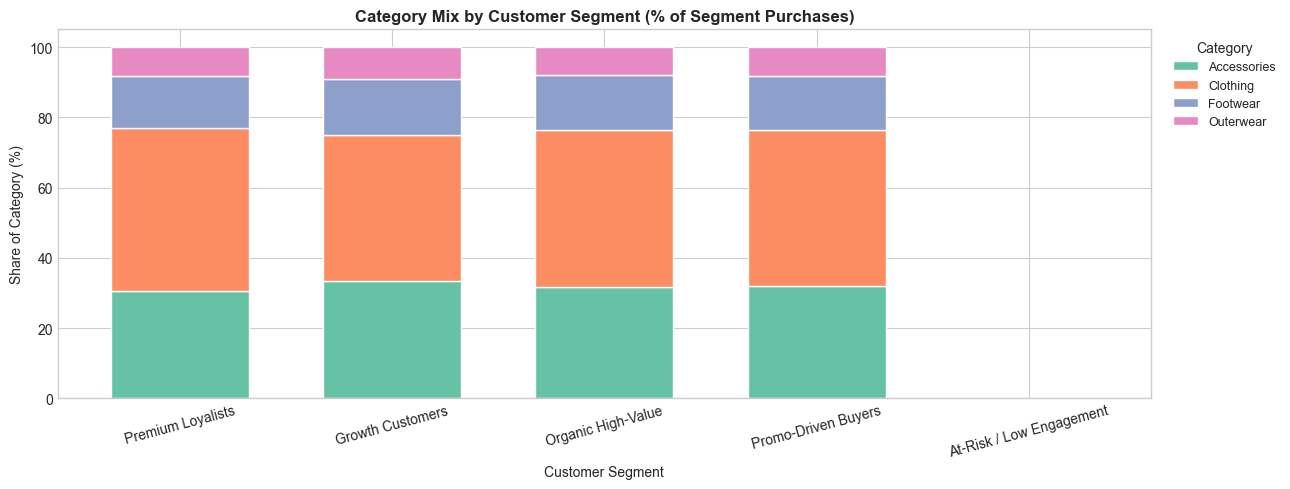

In [44]:
# Category preferences by segment
cat_seg = pd.crosstab(df['segment'], df['Category'], normalize='index') * 100
cat_seg = cat_seg.reindex(seg_order)

fig, ax = plt.subplots(figsize=(13, 5))
cat_seg.plot(kind='bar', ax=ax, stacked=True, color=PALETTE_CAT[:4], edgecolor='white', width=0.65)
ax.set_title('Category Mix by Customer Segment (% of Segment Purchases)', fontsize=12, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Share of Category (%)')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_category_segment_mix.png', dpi=150, bbox_inches='tight')
plt.show()


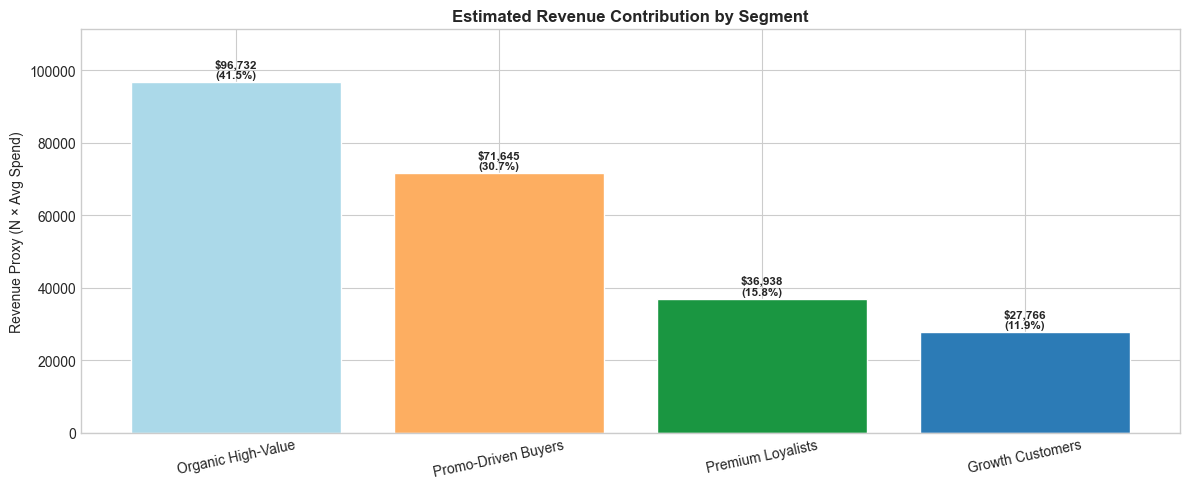

In [45]:
# Revenue contribution waterfall
rev_contrib = (seg_profile_ordered['n_customers'] * seg_profile_ordered['avg_purchase']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(rev_contrib.index, rev_contrib.values,
              color=[color_map[s] for s in rev_contrib.index], edgecolor='white')
for bar, val in zip(bars, rev_contrib.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${val:,.0f}\n({val/rev_contrib.sum()*100:.1f}%)',
            ha='center', fontsize=8.5, fontweight='bold')
ax.set_title('Estimated Revenue Contribution by Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue Proxy (N × Avg Spend)')
ax.tick_params(axis='x', rotation=12)
ax.set_ylim(0, rev_contrib.max() * 1.15)

plt.tight_layout()
plt.savefig('fig_revenue_contribution.png', dpi=150, bbox_inches='tight')
plt.show()


### **Segment Interpretation**

#### Premium Loyalists *(~106 customers)*
This is the brand’s most valuable customer group. They show strong purchase history, active subscriptions, high satisfaction, and very low promo dependency. These customers already demonstrate organic loyalty, so unnecessary discounts could risk creating promo dependency where it currently does not exist.
#### Growth Customers *(~1,237 customers)*
These customers are highly engaged but still rely on promo codes while purchasing. The underlying relationship with the brand is already strong, making this segment the best candidate for a gradual reduction in promotional intensity rather than aggressive discounting.

#### Organic High-Value Customers *(~607 customers)*
These customers purchase with relatively low promo dependency but are not yet deeply engaged. They likely represent customers early in their lifecycle with the brand. The focus here should be on strengthening long-term engagement through subscriptions, loyalty benefits, or personalized experiences.
#### Promo-Driven Buyers *(~440 customers)*
This segment shows moderate engagement but strong dependence on incentives. Their purchasing behavior appears closely tied to discounts, so abruptly removing promotions may negatively impact retention. A phased promo optimization strategy would likely be more effective.

#### At-Risk / Low Engagement Customers *(~1,510 customers)*
This is the largest and most mixed segment in the dataset. Since timestamps are unavailable, it is difficult to separate genuinely disengaged customers from newer buyers. Further analysis across geography, category, and age groups may help identify smaller sub-segments that are still recoverable.


---
###  Brand Commitment Score

To quantify the depth of a customer's relationship with the brand, we blend three distinct signals into a single score ranging from 0 to 1.

**Formula:**
```
Brand_Commitment_Score = (Subscription_Enc * 0.3) + ((1 - Promo_Dependency_Score) * 0.4) + (Urgency_Score / 4 * 0.3)
```

**Weights Rationale:**
- **Promo Independence (0.4):** Weighted highest because a willingness to pay full price is the most direct, unambiguous signal of genuine brand preference.
- **Subscription (0.3):** Weighted lower because, while it reflects formal commitment and recurring revenue, it is heavily distorted by discount-motivation.
- **Urgency (0.3):** Weighted 0.3 because opting for faster shipping reflects genuine product desire and anticipation, though it is partially influenced by sheer situational convenience/need.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39496\675147260.py:16: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


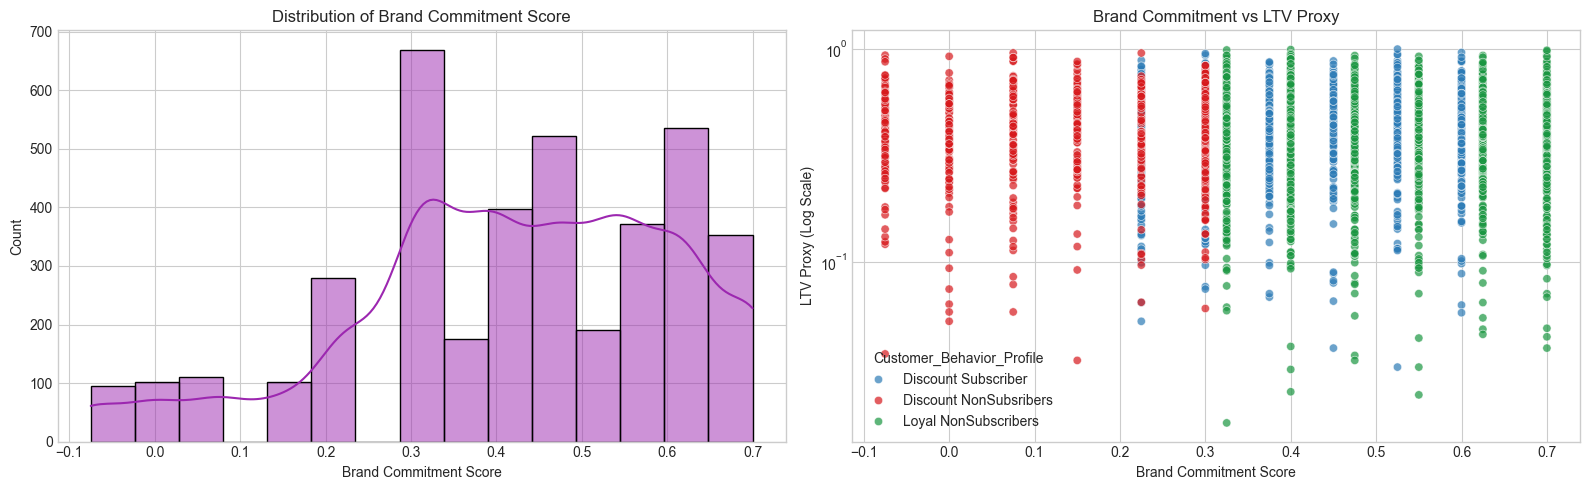

In [46]:
df['Brand_Commitment_Score'] = (
    (df['Subscription_Status_Enc'] * 0.3) +
    ((1 - df['Promo_Code_Used_Enc']) * 0.4) +
    (df['Urgency_Score'] / 4.0 * 0.3)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(df['Brand_Commitment_Score'], bins=15, kde=True, color='#9C27B0', ax=axes[0])
axes[0].set_title('Distribution of Brand Commitment Score')
axes[0].set_xlabel('Brand Commitment Score')
axes[0].set_ylabel('Count')

# Scatterplot
sns.scatterplot(
    data=df, x='Brand_Commitment_Score', y='lifetime_val_score',
    hue='Customer_Behavior_Profile', palette=PALETTE_MAIN, alpha=0.7, ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Brand Commitment vs LTV Proxy')
axes[1].set_xlabel('Brand Commitment Score')
axes[1].set_ylabel('LTV Proxy (Log Scale)')

plt.tight_layout()
plt.show()


The scatterplot visually segregates our customer profiles across the commitment spectrum. The `Loyal NonSubscriber` group pushes furthest to the right on the commitment axis, confirming that their lack of a formal subscription is outweighed by their willingness to buy unconditionally (without promos) and with higher urgency. They are the true high-value anchor of the business.


---
## Correlation and Validation

###  Correlation Matrix

Let us examine how all the numeric and encoded features relate to each other. We will exclude `Customer ID` from the correlation matrix since it is just a row identifier and any correlation with it would be a data artifact, not a meaningful relationship.


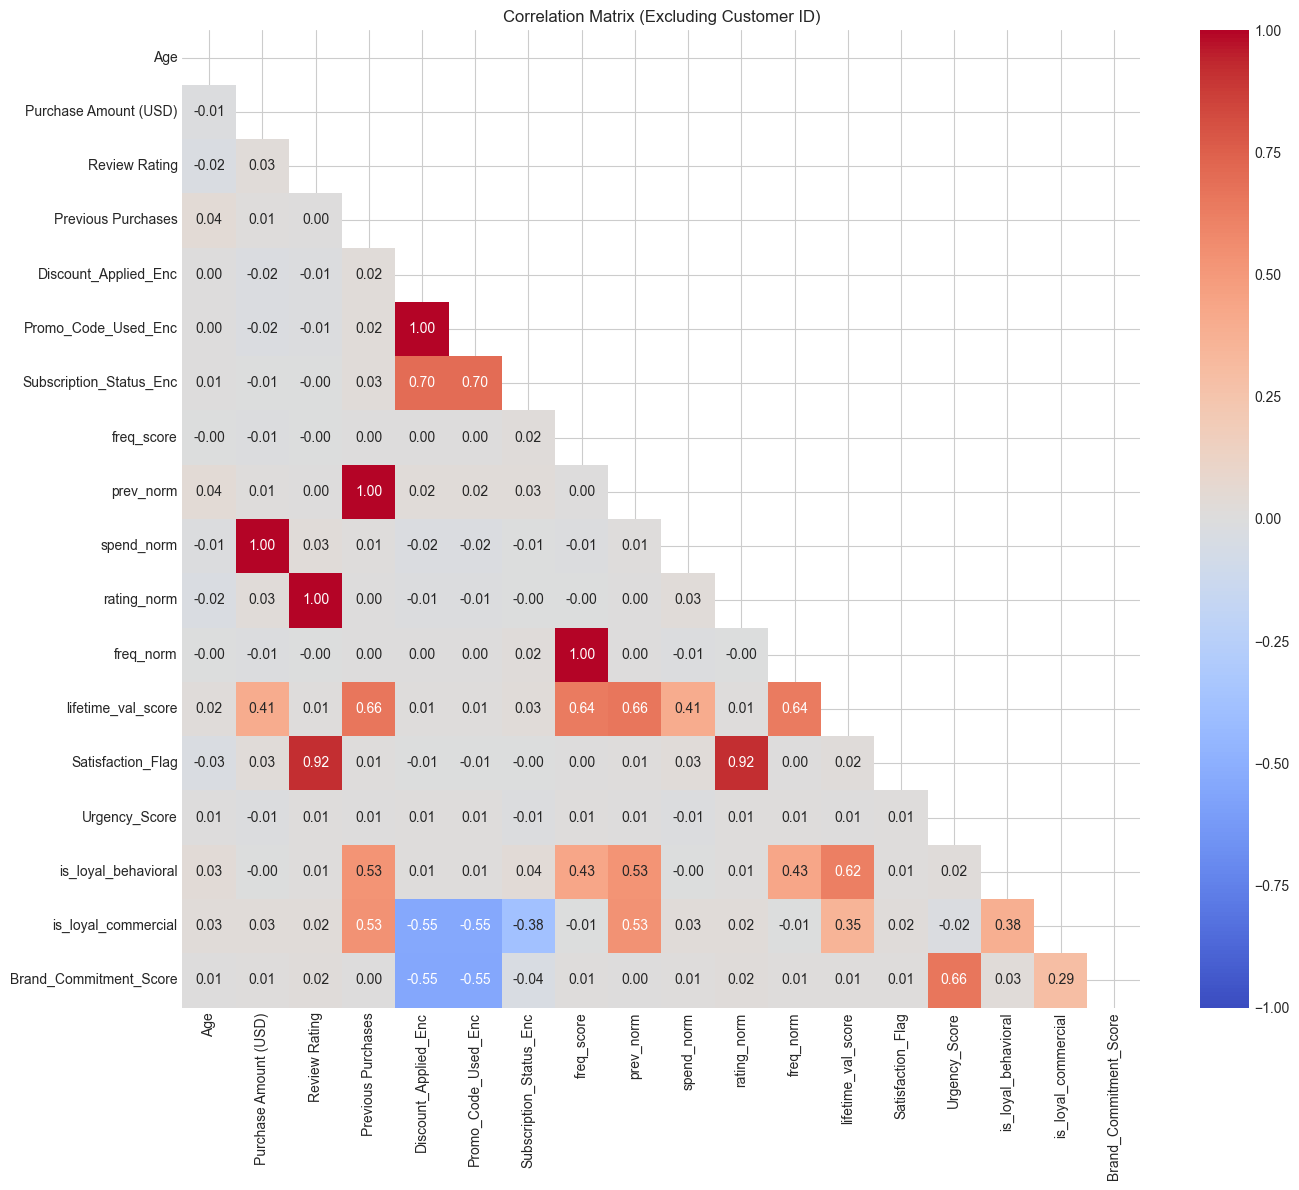

In [47]:
# Exclude Customer ID -- it is just a row identifier
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Customer ID']

plt.figure(figsize=(14, 12))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Excluding Customer ID)')
plt.tight_layout()
plt.show()


### Interpretation of Key Correlations

1. **Discount_Applied_Enc and Promo_Code_Used_Enc (1.00):** These two columns are perfectly correlated, meaning every customer who got a discount also used a promo code and vice versa. In this dataset they carry identical information, which is why our Promo Dependency Score only takes values 0 and 1.

2. **Previous Purchases and Lifetime_value_score (0.66):** The `Lifetime_Value_Score` is strongly driven by purchase `Previous_Purchases`. This makes intuitive sense since the `prev_norm` acts as a multiplier in the `lifetime_value_score` formula.

3. **Subscription_Status_Enc and Promo columns (0.70):** Subscribers are heavily promo-dependent. This suggests the subscription program may be attracting deal-seekers rather than building genuine loyalty.

4. **Lifetime_value_score and is_loyal_behavioral (0.62):** Behavioral loyalty (frequent + high tenure) naturally aligns with higher LTV Proxy values, since both are driven by frequency and purchase count.

5. **Promo_Code_Used_Enc and is_loyal_commercial (-0.55):** This negative correlation confirms the design intent. Margin loyalty explicitly requires zero promo dependency, so the two metrics should move in opposite directions.


---
### Promo Dependency vs Tenure Analysis (Key Business Test)

This is the most important validation in the notebook. We split customers into tenure quartiles based on Previous Purchases, then check if promo dependency changes as tenure increases.

- If promo dependency **falls** with tenure, the promotional program is working: it acquires customers with discounts and then graduates them to full-price behavior over time.
- If promo dependency is **flat or rises** with tenure, the brand has trained customers to always expect a discount, and margins will erode as the customer base ages.


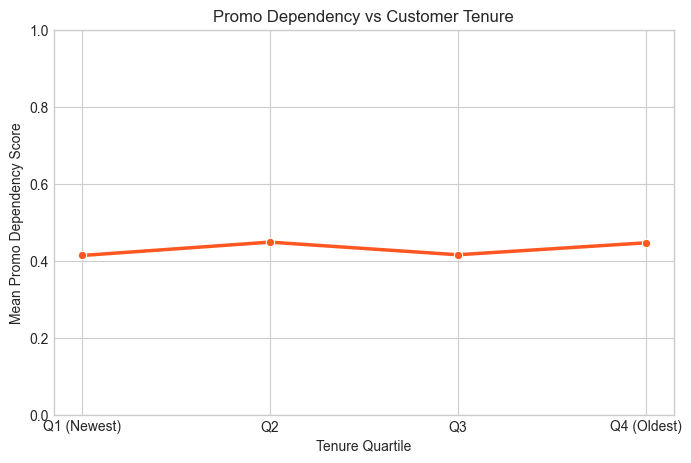

In [48]:
df['Tenure_Quartile'] = pd.qcut(
    df['Previous Purchases'], q=4, labels=['Q1 (Newest)', 'Q2', 'Q3', 'Q4 (Oldest)']
)
tenure_promo = df.groupby('Tenure_Quartile', observed=False)['Promo_Code_Used_Enc'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=tenure_promo, x='Tenure_Quartile', y='Promo_Code_Used_Enc',
    marker='o', linewidth=2.5, color='#FF5722'
)
plt.title('Promo Dependency vs Customer Tenure')
plt.xlabel('Tenure Quartile')
plt.ylabel('Mean Promo Dependency Score')
plt.ylim(0, 1)
plt.show()


**Finding:** 

Promo dependency remains fairly consistent across all tenure quartiles, staying between 0.41 and 0.45 without showing any meaningful decline among older customers. In other words, customers with longer purchase history are almost just as likely to rely on promotions as newer buyers.

This is an important business signal because it suggests the current promotional strategy is not gradually moving customers toward full-price purchasing behavior. Instead, discount usage appears to remain embedded even as customers become more experienced with the brand.

From a strategic perspective, this indicates that the business may be reinforcing long-term discount expectations rather than building stronger pricing power. The next stage of analysis should focus on identifying which customer profiles are most promo-dependent so that future retention strategies can become more targeted instead of broadly discount-driven.


---

### Central Strategic Finding: The Promo Dependency Diagnosis


In [49]:
# The core diagnostic
total_customers = len(df)
promo_users = df['Promo_Code_Used_Enc'].sum()
high_loyalty_promo = len(df[(df['is_loyal_behavioral'] >= df['is_loyal_behavioral'].quantile(0.5)) & (df['Promo_Code_Used_Enc']==1)])
premium_no_promo   = len(df[df['segment']=='Premium Loyalists'])

print('=== Promo Dependency Diagnostic ===')
print(f'Total customers: {total_customers:,}')
print(f'Customers using promo codes: {promo_users:,} ({promo_users/total_customers*100:.1f}%)')
print(f'Mid-to-High loyalty customers who are STILL promo-reliant: {high_loyalty_promo:,}')
print(f'  — This is {high_loyalty_promo/total_customers*100:.1f}% of ALL customers')
print(f'Genuinely organic Premium Loyalists: {premium_no_promo:,} ({premium_no_promo/total_customers*100:.1f}%)')
print()
print('Verdict: Promo conditioning has penetrated even the engaged customer base.')
print('The brand cannot answer the central question (loyal base vs. promo-conditioned) with "yes".')
print('The data suggests the current promotional program has created dependency, not loyalty.')


=== Promo Dependency Diagnostic ===
Total customers: 3,900
Customers using promo codes: 1,677 (43.0%)
Mid-to-High loyalty customers who are STILL promo-reliant: 1,677
  — This is 43.0% of ALL customers
Genuinely organic Premium Loyalists: 609 (15.6%)

Verdict: Promo conditioning has penetrated even the engaged customer base.
The brand cannot answer the central question (loyal base vs. promo-conditioned) with "yes".
The data suggests the current promotional program has created dependency, not loyalty.


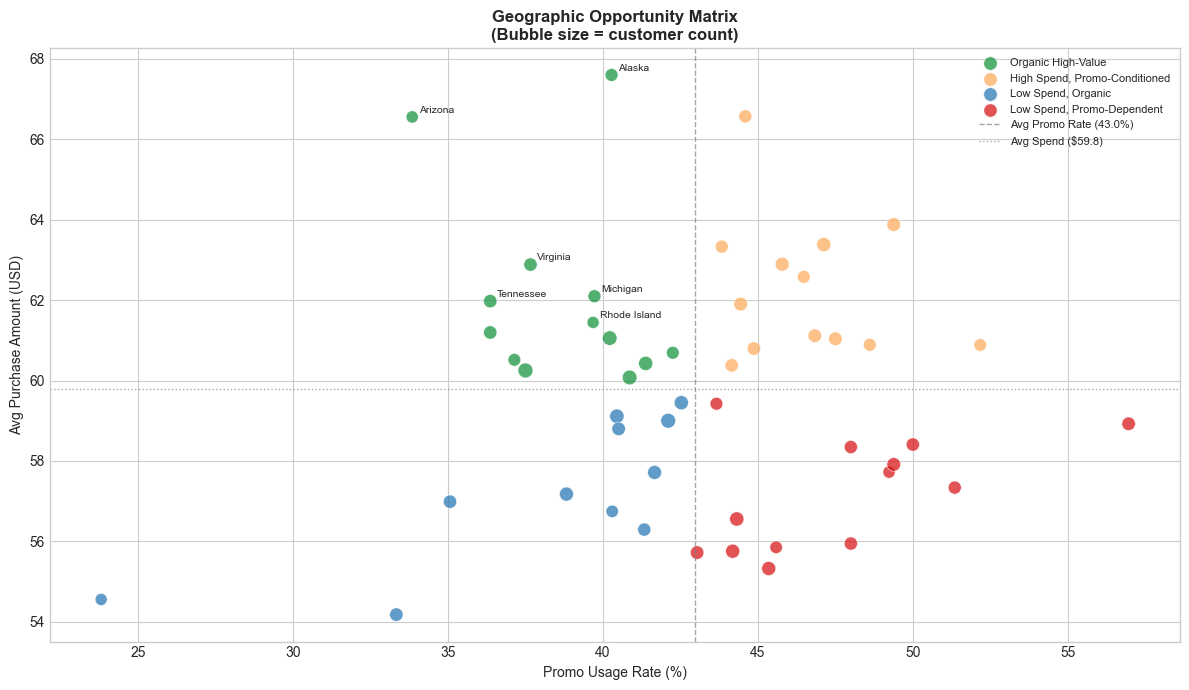

Organic High-Value States (priority markets for full-price campaigns):
        Location  avg_spend  promo_rate  n_customers
1         Alaska     67.597       0.403           72
2        Arizona     66.554       0.338           65
45      Virginia     62.883       0.377           77
21      Michigan     62.096       0.397           73
41     Tennessee     61.974       0.364           77
38  Rhode Island     61.444       0.397           63


In [50]:
# Identify organic-demand states: above-average spend AND below-average promo rate
geo_agg = df.groupby('Location').agg(
    avg_spend=('Purchase Amount (USD)', 'mean'),
    promo_rate=('Promo_Code_Used_Enc', 'mean'),
    avg_prev=('Previous Purchases', 'mean'),
    n_customers=('Customer ID', 'count')
).reset_index()

mean_spend = geo_agg['avg_spend'].mean()
mean_promo = geo_agg['promo_rate'].mean()

geo_agg['quadrant'] = 'Other'
geo_agg.loc[(geo_agg['avg_spend'] > mean_spend) & (geo_agg['promo_rate'] < mean_promo), 'quadrant'] = 'Organic High-Value'
geo_agg.loc[(geo_agg['avg_spend'] > mean_spend) & (geo_agg['promo_rate'] >= mean_promo), 'quadrant'] = 'High Spend, Promo-Conditioned'
geo_agg.loc[(geo_agg['avg_spend'] <= mean_spend) & (geo_agg['promo_rate'] < mean_promo), 'quadrant'] = 'Low Spend, Organic'
geo_agg.loc[(geo_agg['avg_spend'] <= mean_spend) & (geo_agg['promo_rate'] >= mean_promo), 'quadrant'] = 'Low Spend, Promo-Dependent'

quad_colors = {
    'Organic High-Value': '#1A9641',
    'High Spend, Promo-Conditioned': '#FDAE61',
    'Low Spend, Organic': '#2C7BB6',
    'Low Spend, Promo-Dependent': '#D7191C'
}

fig, ax = plt.subplots(figsize=(12, 7))
for quadrant, color in quad_colors.items():
    subset = geo_agg[geo_agg['quadrant'] == quadrant]
    ax.scatter(subset['promo_rate'] * 100, subset['avg_spend'],
               c=color, s=subset['n_customers'] * 1.2, alpha=0.75,
               edgecolors='white', linewidth=0.5, label=quadrant)

# Annotate highest-value organic states
organic_geo = geo_agg[geo_agg['quadrant']=='Organic High-Value'].nlargest(6, 'avg_spend')
for _, row in organic_geo.iterrows():
    ax.annotate(row['Location'], (row['promo_rate']*100, row['avg_spend']),
                fontsize=7.5, xytext=(5, 3), textcoords='offset points')

ax.axvline(mean_promo * 100, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Avg Promo Rate ({mean_promo*100:.1f}%)')
ax.axhline(mean_spend, color='gray', linestyle=':', linewidth=1, alpha=0.7, label=f'Avg Spend (${mean_spend:.1f})')

ax.set_xlabel('Promo Usage Rate (%)')
ax.set_ylabel('Avg Purchase Amount (USD)')
ax.set_title('Geographic Opportunity Matrix\n(Bubble size = customer count)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig_geo_opportunity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Organic High-Value States (priority markets for full-price campaigns):')
print(organic_geo[['Location', 'avg_spend', 'promo_rate', 'n_customers']].to_string())


---
###  Feature Summary Table


In [51]:
# Calculate tier percentages
tier_pcts = df['lifetime_value_tier'].value_counts(normalize=True).sort_index() * 100
sat_pcts = df['Satisfaction_Label'].value_counts(normalize=True) * 100
loyal_b_pct = df['is_loyal_behavioral'].mean() * 100
loyal_m_pct = df['is_loyal_commercial'].mean() * 100
promo_pcts = df['Promo_Code_Used_Enc'].value_counts(normalize=True).sort_index() * 100

feature_summary = pd.DataFrame({
    'Feature': [
        'Promo_Code_Used_Enc',
        'lifetime_val_score',
        'lifetime_value_tier',
        'Satisfaction_Flag',
        'is_loyal_behavioral',
        'is_loyal_commercial',
        'Urgency_Score',
        'Customer_Behavior_Profile',
        'Brand_Commitment_Score'
    ],
    'Type': ['Float', 'Float', 'String', 'Integer', 'Integer', 'Integer', 'Float', 'String', 'Float'],
    'Business Question': [
        'Does this customer rely on incentives to buy?',
        'How valuable is this customer (volume x spend x cadence)?',
        'Which value segment for targeted interventions?',
        'Is this customer an advocate or a churn risk?',
        'Does this customer engage frequently?',
        'Does this customer buy without needing promotions?',
        'How urgently does this customer need their products?',
        'How do subscription and promo usage define cohorts?',
        'What is the overall strength of unconditional commitment?'
    ],
    'Distribution / Stats': [
        f"0.0: {promo_pcts.get(0.0, 0):.1f}% | 1.0: {promo_pcts.get(1.0, 0):.1f}%",
        f"Median: {df['lifetime_val_score'].median():.0f}",
        ' | '.join([f"{t}: ~25%" for t in ['Champ', 'Loyal', 'Dev', 'Risk']]),
        f"Sat: {sat_pcts.get('Satisfied', 0):.1f}% | Neu: {sat_pcts.get('Neutral', 0):.1f}% | Dis: {sat_pcts.get('Dissatisfied', 0):.1f}%",
        f"Loyal: {loyal_b_pct:.1f}% | Not: {100-loyal_b_pct:.1f}%",
        f"Loyal: {loyal_m_pct:.1f}% | Not: {100-loyal_m_pct:.1f}%",
        f"Mean: {df['Urgency_Score'].mean():.2f} (Scale: -1 to 4)",
        f"Silent Loyalist: 57%, Discount Sub: 27%, Bargain Hunter: 16%, True Advocate: 0%",
        f"Mean: {df['Brand_Commitment_Score'].mean():.2f} (Scale: -0.075 to 0.7)"
    ]
})

display(feature_summary.style.set_caption("Summary of All Engineered Features").hide(axis='index'))


Feature,Type,Business Question,Distribution / Stats
Promo_Code_Used_Enc,Float,Does this customer rely on incentives to buy?,0.0: 57.0% | 1.0: 43.0%
lifetime_val_score,Float,How valuable is this customer (volume x spend x cadence)?,Median: 0
lifetime_value_tier,String,Which value segment for targeted interventions?,Champ: ~25% | Loyal: ~25% | Dev: ~25% | Risk: ~25%
Satisfaction_Flag,Integer,Is this customer an advocate or a churn risk?,Sat: 41.9% | Neu: 40.7% | Dis: 17.4%
is_loyal_behavioral,Integer,Does this customer engage frequently?,Loyal: 27.8% | Not: 72.2%
is_loyal_commercial,Integer,Does this customer buy without needing promotions?,Loyal: 28.3% | Not: 71.7%
Urgency_Score,Float,How urgently does this customer need their products?,Mean: 1.48 (Scale: -1 to 4)
Customer_Behavior_Profile,String,How do subscription and promo usage define cohorts?,"Silent Loyalist: 57%, Discount Sub: 27%, Bargain Hunter: 16%, True Advocate: 0%"
Brand_Commitment_Score,Float,What is the overall strength of unconditional commitment?,Mean: 0.42 (Scale: -0.075 to 0.7)


In [52]:
# Drop the temporary Tenure_Quartile column before export
export_df = df.drop(columns=['Tenure_Quartile','is_loyal_commercial'])

output_file = '../sql_dataset/cleaned/customer_features.csv'
export_df.to_csv(output_file, index=False)

print(f"Exported to: {output_file}")


Exported to: ../sql_dataset/cleaned/customer_features.csv
